In [9]:
# Standard library
import os
import glob
import math
import random
import calendar
from pathlib import Path
import zipfile
import time

# Scientific stack
import numpy as np
import pandas as pd
import xarray as xr
from scipy import stats
from scipy.stats import gaussian_kde

# Machine learning / compute
import dask
import sklearn

# Geospatial
import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io import shapereader
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.interpolate import RegularGridInterpolator

# Visualization
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# External models
from pythermalcomfort.models import utci as py_utci
from utci_nn_model3 import UTCIPredictor

# APIs
import cdsapi


import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
#from cartopy import shapereader
import numpy as np
import xarray as xr
import glob
from pathlib import Path
import numpy as np
import xarray as xr
import numpy as np
import xarray as xr
import geopandas as gpd
from shapely.geometry import Point
from shapely.prepared import prep
from cartopy.io import shapereader
from typing import Union, Tuple

import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors


In [10]:
def compute_RH_from_Td_T(d2m_celsius, t2m_celsius):
    """Compute relative humidity from dew point temperature and air temperature 
    using the Clausius-Clapeyron equation (August-Roche-Magnus formula).

    Parameters
    ----------
    d2m_celsius : float or np.ndarray
        Dew point temperature in degrees Celsius.
    t2m_celsius : float or np.ndarray
        Air temperature in degrees Celsius.

    Returns
    -------
    RH : float or np.ndarray
        Relative humidity in percentage (%).
    """
    # Use numpy's exp for vectorized operations
    es_td = np.exp((17.625 * d2m_celsius) / (243.04 + d2m_celsius))
    es_t = np.exp((17.625 * t2m_celsius) / (243.04 + t2m_celsius))
    
    RH = 100 * (es_td / es_t)
    
    return RH

In [11]:
def count_hours_relative_to_threshold(
    arr,
    threshold: float,
    mode: str = "below",
    time_dim: str = "time",
):
    """
    Count hours above or below a given threshold.

    Parameters
    ----------
    arr : xarray.DataArray, xarray.Dataset, or numpy.ndarray
        3D array with shape (time, lat, lon).
        If Dataset is provided, the first data variable is used.
    threshold : float
        Threshold value (e.g. UTCI in °C).
    mode : {"below", "above"}
        - "below": count hours where arr < threshold
        - "above": count hours where arr > threshold
    time_dim : str
        Name of time dimension (only used for xarray inputs).

    Returns
    -------
    numpy.ndarray
        2D array (lat, lon) with counts of hours meeting the criterion.
    """

    if mode not in {"below", "above"}:
        raise ValueError("mode must be either 'below' or 'above'")

    # Define comparison operator
    if mode == "below":
        compare = lambda x: x < threshold
    else:
        compare = lambda x: x > threshold

    # ---- xarray input ----
    if isinstance(arr, (xr.DataArray, xr.Dataset)):
        if isinstance(arr, xr.Dataset):
            if len(arr.data_vars) != 1:
                raise ValueError("Dataset must contain exactly one data variable")
            arr = next(iter(arr.data_vars.values()))

        if time_dim not in arr.dims:
            raise ValueError(f"time_dim '{time_dim}' not found in array dims {arr.dims}")

        counts = compare(arr).sum(dim=time_dim, skipna=True)
        return counts.values.astype(np.float64)

    # ---- numpy input ----
    a = np.asarray(arr)
    if a.ndim != 3:
        raise ValueError(f"Expected 3D array (time, lat, lon), got shape {a.shape}")

    return np.sum(compare(a), axis=0).astype(np.float64)

In [12]:
# -----------------------------
# LAND MASK FUNCTION
# -----------------------------
def create_land_mask(
    ds: xr.Dataset,
    lon_name: str = "lon",
    lat_name: str = "lat",
    nat_earth_resolution: str = "110m",
    nat_earth_category: str = "cultural",
    nat_earth_name: str = "admin_0_countries",
    lon_range: str = "auto",
    prepared: bool = True,
) -> xr.DataArray:
    """
    Generate a boolean land mask (True = land, False = sea) aligned to the
    lon/lat grid of the provided xarray Dataset `ds`.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset that contains coordinate arrays for longitude and latitude.
    lon_name : str
        Name of longitude coord in ds (default "lon").
    lat_name : str
        Name of latitude coord in ds (default "lat").
    nat_earth_resolution : str
        Natural Earth resolution string passed to cartopy.shapereader.natural_earth.
    nat_earth_category : str
        Category passed to shapereader (default "cultural").
    nat_earth_name : str
        Name passed to shapereader (default "admin_0_countries").
    lon_range : {"auto", "wrap180", "preserve"}
        How to treat longitudes before point-in-polygon:
          - "auto": detect if lon in 0..360 and wrap to -180..180 if needed.
          - "wrap180": always map lon values > 180 to lon-360 (so coords in -180..180)
          - "preserve": do not modify longitudes
    prepared : bool
        If True create a prepared geometry for faster contains tests (recommended).

    Returns
    -------
    xr.DataArray
        2D boolean DataArray with dims (lat, lon) and coords copied from ds.
    """

    # --- validate coords ---
    if lon_name not in ds.coords or lat_name not in ds.coords:
        raise ValueError(f"Dataset must contain coords '{lon_name}' and '{lat_name}'")

    lons = ds[lon_name].values
    lats = ds[lat_name].values

    # Ensure lons and lats are 1D
    if lons.ndim != 1 or lats.ndim != 1:
        raise ValueError("Longitude and latitude coordinates must be 1D arrays")

    # --- fix lon range if requested ---
    if lon_range == "auto":
        if lons.min() >= 0 and lons.max() > 180:
            lon_range = "wrap180"
        else:
            lon_range = "preserve"

    if lon_range == "wrap180":
        # create a wrapped lon array (not changing ds itself)
        lons_wrapped = np.where(lons > 180, lons - 360, lons)
    else:
        lons_wrapped = lons.copy()

    # Build meshgrid of lon/lat for point creation (lon along axis 1, lat along axis 0)
    lon2d, lat2d = np.meshgrid(lons_wrapped, lats)

    # --- load Natural Earth geometries ---
    shp_path = shapereader.natural_earth(
        resolution=nat_earth_resolution,
        category=nat_earth_category,
        name=nat_earth_name,
    )
    gdf = gpd.read_file(shp_path)
    union_geom = gdf.unary_union
    test_geom = prep(union_geom) if prepared else union_geom

    # --- create points and test containment ---
    # NOTE: constructing Python Point objects in a list comprehension can be memory-heavy
    # for very high-resolution grids. This approach is simple and robust. If you have very
    # large grids, consider processing by rows/chunks.
    pts = (Point(x, y) for x, y in zip(lon2d.ravel(), lat2d.ravel()))
    contains = np.fromiter((test_geom.contains(p) for p in pts), dtype=bool, count=lon2d.size)
    mask_2d = contains.reshape(lon2d.shape)

    # If we wrapped lons earlier, present mask with original ds lon coords (unchanged)
    land_mask = xr.DataArray(
        mask_2d,
        coords={lat_name: ds[lat_name], lon_name: ds[lon_name]},
        dims=(lat_name, lon_name),
        name="land_mask",
    )
    land_mask.attrs["description"] = "Boolean land mask (True=land) based on Natural Earth"
    land_mask.attrs["natural_earth_resolution"] = nat_earth_resolution

    return land_mask


# -----------------------------
# DAYTIME MASK FUNCTION
# -----------------------------
def create_daytime_mask(
    ds: xr.Dataset,
    time_name: str = "time",
    start_hour: int = 6,
    end_hour: int = 18,
    inclusive: bool = True,
    tz_offset_hours: int = 0,
) -> xr.DataArray:
    """
    Create a boolean daytime mask along the dataset time coordinate. Default daytime =
    06:00 to 18:00 inclusive (local hours). Works with xarray datetime64[ns] coords.

    Parameters
    ----------
    ds : xr.Dataset
        Dataset holding the time coordinate
    time_name : str
        Name of the time coordinate (default 'time')
    start_hour : int
        Start hour (0-23) of daytime (default 6)
    end_hour : int
        End hour (0-23) of daytime (default 18)
    inclusive : bool
        If True, include both endpoints (i.e. `isin(range(start,end+1))`).
    tz_offset_hours : int
        If your dataset times are in UTC and you want local daytime, provide timezone
        offset in hours (e.g., for UTC+2 pass tz_offset_hours=2). Negative allowed.

    Returns
    -------
    xr.DataArray
        1D boolean DataArray indexed by time (same coords as ds[time_name])
    """

    if time_name not in ds.coords:
        raise ValueError(f"Dataset does not contain a time coordinate '{time_name}'")

    time_coord = ds[time_name]

    # apply tz offset as simple hour shift (does not change timezone info)
    if tz_offset_hours != 0:
        shifted_time = time_coord + np.timedelta64(int(tz_offset_hours), "h")
    else:
        shifted_time = time_coord

    hours = shifted_time.dt.hour

    if inclusive:
        # create inclusive range
        if start_hour <= end_hour:
            selected = hours.isin(np.arange(start_hour, end_hour + 1))
        else:
            # wrap-around midnight (e.g., start=20 end=04)
            allowed = np.concatenate((np.arange(start_hour, 24), np.arange(0, end_hour + 1)))
            selected = hours.isin(allowed)
    else:
        # exclusive end
        if start_hour <= end_hour:
            selected = (hours >= start_hour) & (hours < end_hour)
        else:
            selected = (hours >= start_hour) | (hours < end_hour)

    daytime_mask = xr.DataArray(
        selected,
        coords={time_name: ds[time_name]},
        dims=(time_name,),
        name="daytime_mask",
    )
    daytime_mask.attrs["description"] = f"Daytime mask hours {start_hour:02d}:{0:02d} - {end_hour:02d}:{0:02d} (inclusive={inclusive})"
    daytime_mask.attrs["tz_offset_hours"] = tz_offset_hours

    return daytime_mask


In [13]:

# create the predictor object
predictor = UTCIPredictor(model_path="../results/utci_nn_weights.pth",
                          scaler_path="../results/scaler.pkl",
                          device="cpu",
                          batch_size=65536)


## Load the data

### Cold Spell 2012

In [14]:
# =========================
# 1. LOAD MRT DATA (Cold Spell 2012)
# =========================
print("=" * 60)
print("LOADING MRT DATA (Cold Spell 2012)")
print("=" * 60)

# Find all MRT files
mrt_files_coldspell = sorted(glob.glob(r"..\data\2012_coldspell\utci_era5\ECMWF_mrt*.nc"))
print(f"Found {len(mrt_files_coldspell)} MRT files")

# Load MRT data as a single xarray dataset
mrt_coldspell = xr.open_mfdataset(mrt_files_coldspell, combine='by_coords', engine='netcdf4')
mrt_coldspell['mrt_C'] = mrt_coldspell['mrt'] - 273.15  # Convert from Kelvin to Celsius
print(f"MRT dataset loaded: {mrt_coldspell.dims}")

# =========================
# 2. LOAD DiNapoli UTCI DATA (Cold Spell 2012)
# =========================
print("=" * 60)
print("LOADING DiNapoli UTCI DATA (Cold Spell 2012)")
print("=" * 60)

utci_files_coldspell = sorted(glob.glob(r"..\data\2012_coldspell\utci_era5\ECMWF_utci*.nc"))
print(f"Found {len(utci_files_coldspell)} UTCI files")

utci_dinapoli_coldspell = xr.open_mfdataset(utci_files_coldspell, combine='by_coords', engine='netcdf4')
utci_dinapoli_coldspell['utci_C'] = utci_dinapoli_coldspell['utci'] - 273.15
print(f"UTCI dataset loaded: {utci_dinapoli_coldspell.dims}")

# =========================
# 3. LOAD ERA5 ENVIRONMENTAL VARIABLES (Cold Spell 2012)
# =========================
data_dir_coldspell = Path("../data/2012_coldspell/input_era5/")
variables = ['u10', 'v10', 'd2m', 't2m']  # Variables to process
era5_env_coldspell = {}  # Dictionary to store datasets

for var in variables:
    print(f"Processing {var.upper()}...")
    var_files = sorted(glob.glob(str(data_dir_coldspell / f"{var}_*.nc")))
    
    if not var_files:
        print(f"  No files found for {var}")
        continue
    
    print(f"  Found {len(var_files)} file(s)")
    
    ds_combined = xr.open_mfdataset(
        var_files,
        combine='by_coords',
        parallel=True,
        chunks={'time': 100}  # Adjust chunk size as needed
    )
    
    era5_env_coldspell[var] = ds_combined
    print(f"  ✓ Combined shape: {ds_combined[var].shape}")

# =========================
# 4. CREATE INPUT DATASET FOR 2012 COLD SPELL
# =========================
input_2012_coldspell = mrt_coldspell.copy()

# Convert air temperature to Celsius
input_2012_coldspell['t2m_C'] = era5_env_coldspell['t2m']['t2m'] - 273.15

# Calculate wind speed from u10 and v10 components
u10 = era5_env_coldspell['u10']['u10']
v10 = era5_env_coldspell['v10']['v10']
input_2012_coldspell['wind_speed_10m'] = np.sqrt(u10**2 + v10**2)
input_2012_coldspell['wind_speed_10m'].attrs['units'] = 'm/s'

# Calculate relative humidity from dew point and air temperature
Ta = input_2012_coldspell['t2m_C']
Td = era5_env_coldspell['d2m']['d2m'] - 273.15
RH = compute_RH_from_Td_T(Td, Ta)  # Ensure this function is defined elsewhere
input_2012_coldspell['rH'] = (Ta.dims, RH.data)  # Match dimensions

# Keep original dew point in Kelvin for reference
input_2012_coldspell['d2m_K'] = era5_env_coldspell['d2m']['d2m']

# =========================
# 5. PREDICT UTCI USING NEURAL NETWORK (Cold Spell 2012)
# =========================
utci_NN_values = predictor.predict(
    Ta=input_2012_coldspell['t2m_C'],
    Tr=input_2012_coldspell['mrt_C'],
    va=input_2012_coldspell['wind_speed_10m'],
    rH=input_2012_coldspell['rH']
)

# Convert to xarray DataArray
utci_NN_coldspell = xr.DataArray(
    utci_NN_values,
    coords={
        "time": utci_dinapoli_coldspell["time"],
        "lat": utci_dinapoli_coldspell["lat"],
        "lon": utci_dinapoli_coldspell["lon"]
    },
    dims=("time", "lat", "lon"),
    name="utci_NN"
)
utci_NN_coldspell.attrs.update({
    "description": "UTCI calculated using NN method",
    "units": "°C"
})
utci_NN_coldspell = xr.Dataset({"utci_NN": utci_NN_coldspell})

# =========================
# 6. CALCULATE UTCI DIFFERENCE
# =========================
utci_diff_coldspell = utci_NN_coldspell['utci_NN'] - utci_dinapoli_coldspell['utci_C']

# Helper function to fix dimension names
def fix_dims(da):
    return da.rename({
        "valid_time": "time",
        "latitude": "lat",
        "longitude": "lon",
    })

# Apply fixed dimensions
Ta  = fix_dims(input_2012_coldspell['t2m_C'])
Tr  = input_2012_coldspell['mrt_C']
va  = fix_dims(input_2012_coldspell['wind_speed_10m'])
rH  = fix_dims(input_2012_coldspell['rH'])

# =========================
# 7. COMPILE FINAL DATASET
# =========================
results_2012_coldspell = xr.Dataset({
    "Ta": Ta,
    "Tr": Tr,
    "va": va,
    "rH": rH,
    "utci_NN": utci_NN_coldspell['utci_NN'],
    "utci_DiNapoli": utci_dinapoli_coldspell['utci_C'],
    "utci_diff": utci_diff_coldspell
})

print("Cold spell 2012 data processing complete. Use 'results_2012_coldspell' for analysis.")



LOADING MRT DATA (Cold Spell 2012)
Found 60 MRT files
MRT dataset loaded: FrozenMappingWarningOnValuesAccess({'time': 1440, 'lat': 149, 'lon': 281})
LOADING DiNapoli UTCI DATA (Cold Spell 2012)
Found 60 UTCI files
UTCI dataset loaded: FrozenMappingWarningOnValuesAccess({'time': 1440, 'lat': 149, 'lon': 281})
Processing U10...
  Found 2 file(s)
  ✓ Combined shape: (1440, 149, 281)
Processing V10...
  Found 2 file(s)
  ✓ Combined shape: (1440, 149, 281)
Processing D2M...
  Found 2 file(s)
  ✓ Combined shape: (1440, 149, 281)
Processing T2M...
  Found 2 file(s)
  ✓ Combined shape: (1440, 149, 281)
Cold spell 2012 data processing complete. Use 'results_2012_coldspell' for analysis.


### Heatwave 2003

In [15]:
# =========================
# 1. Load MRT and DiNapoli UTCI data
# =========================
mrt_files = sorted(glob.glob(r"..\data\2003_heatwave\utci_era5\ECMWF_mrt*.nc"))
mrt = xr.open_mfdataset(mrt_files, combine='by_coords', engine='netcdf4')
mrt['mrt_C'] = mrt['mrt'] - 273.15

utci_files = sorted(glob.glob(r"..\data\2003_heatwave\utci_era5\ECMWF_utci*.nc"))
utci_dinapoli = xr.open_mfdataset(utci_files, combine='by_coords', engine='netcdf4')
utci_dinapoli['utci_C'] = utci_dinapoli['utci'] - 273.15

# %%
# =========================
# 2. Load ERA5 environmental variables
# =========================
data_dir = Path("../data/2003_heatwave/input_era5/")
variables = ['u10', 'v10', 'd2m', 't2m']
era5_env = {}

for var in variables:
    files = sorted(glob.glob(str(data_dir / f"{var}_*.nc")))
    if files:
        era5_env[var] = xr.open_mfdataset(files, combine='by_coords', parallel=True, chunks={'time': 100})
        print(f"{var} loaded: {era5_env[var][var].shape}")

# %%
# =========================
# 3. Preprocess: wind speed, RH, etc.
# =========================
def compute_RH_from_Td_T(d2m_celsius, t2m_celsius):
    es_td = np.exp((17.625 * d2m_celsius) / (243.04 + d2m_celsius))
    es_t = np.exp((17.625 * t2m_celsius) / (243.04 + t2m_celsius))
    return 100 * (es_td / es_t)

input_2003 = mrt.copy()
input_2003['t2m_C'] = era5_env['t2m']['t2m'] - 273.15
u10 = era5_env['u10']['u10']
v10 = era5_env['v10']['v10']
input_2003['wind_speed_10m'] = np.sqrt(u10**2 + v10**2)
Td = era5_env['d2m']['d2m'] - 273.15
input_2003['rH'] = (input_2003['t2m_C'].dims, compute_RH_from_Td_T(Td, input_2003['t2m_C']).data)

# %%
# =========================
# 4. Predict UTCI using NN
# =========================
utci_NN_values = predictor.predict(
    Ta=input_2003['t2m_C'],
    Tr=input_2003['mrt_C'],
    va=input_2003['wind_speed_10m'],
    rH=input_2003['rH']
)

utci_NN = xr.DataArray(
    utci_NN_values,
    coords={"time": utci_dinapoli["time"], "lat": utci_dinapoli["lat"], "lon": utci_dinapoli["lon"]},
    dims=("time", "lat", "lon"),
    name="utci_NN"
)
utci_NN = xr.Dataset({"utci_NN": utci_NN})


# =========================
# 6. CALCULATE UTCI DIFFERENCE
# =========================
utci_diff_heatwave = utci_NN['utci_NN'] - utci_dinapoli['utci_C']

# Helper function to fix dimension names
def fix_dims(da):
    return da.rename({
        "valid_time": "time",
        "latitude": "lat",
        "longitude": "lon",
    })

# Apply fixed dimensions
Ta  = fix_dims(input_2003['t2m_C'])
Tr  = input_2003['mrt_C']
va  = fix_dims(input_2003['wind_speed_10m'])
rH  = fix_dims(input_2003['rH'])

# =========================
# 7. COMPILE FINAL DATASET
# =========================
results_2003_heatwave = xr.Dataset({
    "Ta": Ta,
    "Tr": Tr,
    "va": va,
    "rH": rH,
    "utci_NN": utci_NN['utci_NN'],
    "utci_DiNapoli": utci_dinapoli['utci_C'],
    "utci_diff": utci_diff_heatwave
})

print("Heatwave 2003 data processing complete. Use 'results_2003_heatwave' for analysis.")



u10 loaded: (2928, 149, 281)
v10 loaded: (2928, 149, 281)
d2m loaded: (2928, 149, 281)
t2m loaded: (2928, 149, 281)
Heatwave 2003 data processing complete. Use 'results_2003_heatwave' for analysis.


In [16]:
## Find maximum/minimum temp per day for a particular city
def daily_extreme_temp_city(
    daily_data_NN, daily_data_Poly, city_lat, city_lon, extreme: str
):
    # Extract the data for a specific city
    df_NN = daily_data_NN.sel(lat=city_lat, lon=city_lon, method='nearest').to_dataframe()
    df_Poly = daily_data_Poly.sel(lat=city_lat, lon=city_lon, method='nearest').to_dataframe()

    if extreme == 'min':
        ex_by_day_NN = df_NN['utci_NN'].resample('D').min()
        ex_by_day_Poly = df_Poly['utci_DiNapoli'].resample('D').min()

    elif extreme == 'max':   
        ex_by_day_NN = df_NN['utci_NN'].resample('D').max()
        ex_by_day_Poly = df_Poly['utci_DiNapoli'].resample('D').max()

    else:
        raise ValueError("extreme must be either 'min' or 'max'")

    df = pd.DataFrame({
        'utci_NN': ex_by_day_NN,
        'utci_Poly': ex_by_day_Poly
    })
    
    return df

## Create Land Masks

In [17]:
# for cold spell dataset:
land_mask_c = create_land_mask(input_2012_coldspell, lon_name="lon", lat_name="lat")
day_mask_c  = create_daytime_mask(input_2012_coldspell, start_hour=6, end_hour=20, tz_offset_hours=0)

# for heatwave dataset:
land_mask_h = create_land_mask(results_2003_heatwave, lon_name="lon", lat_name="lat")
day_mask_h  = create_daytime_mask(results_2003_heatwave, start_hour=6, end_hour=20, tz_offset_hours=0)


C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\1377940988.py:80: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_geom = gdf.unary_union
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\1377940988.py:80: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  union_geom = gdf.unary_union


## Apply Land and daytime masks

In [18]:
results_2003_heatwave

<xarray.Dataset> Size: 4GB
Dimensions:        (time: 2928, lat: 149, lon: 281)
Coordinates:
  * time           (time) datetime64[ns] 23kB 2003-06-01 ... 2003-09-30T23:00:00
  * lat            (lat) float64 1kB 72.0 71.75 71.5 71.25 ... 35.5 35.25 35.0
  * lon            (lon) float64 2kB -25.0 -24.75 -24.5 ... 44.5 44.75 45.0
    number         int64 8B 0
    expver         (time) <U4 47kB dask.array<chunksize=(720,), meta=np.ndarray>
Data variables:
    Ta             (time, lat, lon) float32 490MB dask.array<chunksize=(360, 75, 141), meta=np.ndarray>
    Tr             (time, lat, lon) float32 490MB dask.array<chunksize=(1, 149, 281), meta=np.ndarray>
    va             (time, lat, lon) float32 490MB dask.array<chunksize=(360, 75, 141), meta=np.ndarray>
    rH             (time, lat, lon) float32 490MB dask.array<chunksize=(360, 75, 141), meta=np.ndarray>
    utci_NN        (time, lat, lon) float64 981MB -6.235 -4.776 ... 17.36 17.0
    utci_DiNapoli  (time, lat, lon) float32 490MB dask.array<chunksize=(1, 149, 281), meta=np.ndarray>
    utci_diff      (time, lat, lon) float64 981MB dask.array<chunksize=(1, 149, 281), meta=np.ndarray>

In [19]:
results_2003_heatwave = results_2003_heatwave.sel(
    time=results_2003_heatwave.time.dt.month.isin([6, 7, 8])
)

In [20]:

# =========================
# 1. APPLY DAYTIME AND LAND MASKS
# =========================
# Select only daytime hours (06:00–20:00) and grid points over land
# results_coldspell_2012_day_land = results_2012_coldspell.sel(time=day_mask_c).where(land_mask_c)
# results_heatwave_2003_day_land = results_2003_heatwave.sel(time=day_mask_h).where(land_mask_h)

results_coldspell_2012_day_land = results_2012_coldspell.where(land_mask_c)
results_heatwave_2003_day_land = results_2003_heatwave.where(land_mask_h)

# =========================
# 2. COMPUTE MEAN UTCI DIFFERENCE OVER LAND & DAYTIME
# =========================
# Average over time to produce a 2D (lat x lon) array
mean_coldspell_utci_diff_land = np.nanmean(results_coldspell_2012_day_land['utci_diff'], axis=0)
mean_heatwave_utci_diff_land = np.nanmean(results_heatwave_2003_day_land['utci_diff'], axis=0)


# =========================
# 3. COMPUTE VARIANCE IN UTCI DIFFERENCE OVER LAND & DAYTIME
# =========================
# Average over time to produce a 2D (lat x lon) array
var_coldspell_utci_diff_land = np.nanvar(results_coldspell_2012_day_land['utci_diff'], axis=0)
var_heatwave_utci_diff_land = np.nanvar(results_heatwave_2003_day_land['utci_diff'], axis=0)

C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\685929861.py:15: RuntimeWarning: Mean of empty slice
  mean_coldspell_utci_diff_land = np.nanmean(results_coldspell_2012_day_land['utci_diff'], axis=0)
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\685929861.py:16: RuntimeWarning: Mean of empty slice
  mean_heatwave_utci_diff_land = np.nanmean(results_heatwave_2003_day_land['utci_diff'], axis=0)
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\685929861.py:23: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_coldspell_utci_diff_land = np.nanvar(results_coldspell_2012_day_land['utci_diff'], axis=0)
C:\Users\nerc-user\AppData\Local\Temp\ipykernel_336\685929861.py:24: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var_heatwave_utci_diff_land = np.nanvar(results_heatwave_2003_day_land['utci_diff'], axis=0)


In [21]:
print("cold", np.nanmean(mean_coldspell_utci_diff_land))
print("heatwave", np.nanmean(mean_heatwave_utci_diff_land))

cold 0.02017862089398756
heatwave 0.16392265187907004


### Count Thermal Stress Hours 

In [22]:
# =========================
# Count Cold Stess for both Methods
# =========================
cold_hours_nn = count_hours_relative_to_threshold(
    results_2012_coldspell["utci_NN"],
    threshold=-13.0,
    mode="below"
)

cold_hours_poly = count_hours_relative_to_threshold(
    results_2012_coldspell["utci_DiNapoli"],
    threshold=-13.0,
    mode="below"
)

# difference
count_diff_c = cold_hours_nn - cold_hours_poly

# Mask invalid or zero-difference cells
both_nan = np.isnan(cold_hours_nn) & np.isnan(cold_hours_poly)
count_diff_c = np.where(both_nan, np.nan, count_diff_c)
count_diff_c = np.where(np.isfinite(count_diff_c), count_diff_c, np.nan)

#Find number of days
n_days_c = results_2012_coldspell['time'].dt.floor('D').to_index().nunique()
# Average difference per day
avg_count_diff_c = np.where(land_mask_c, count_diff_c, np.nan)/n_days_c

print("Average daily difference in cold stress hours (NN - DiNapoli):", np.nanmean(avg_count_diff_c))
print("Average gridcell difference in cold stress hours (NN - DiNapoli):", np.nanmean(avg_count_diff_c)*n_days_c)
print("total difference in cold stress hours (NN - DiNapoli):", np.nansum(count_diff_c))

# =========================
# Count Heat Stess for both Methods
# =========================
heat_hours_nn = count_hours_relative_to_threshold(
    results_2003_heatwave["utci_NN"],
    threshold=32.0,
    mode="above"
)

heat_hours_poly = count_hours_relative_to_threshold(
    results_2003_heatwave["utci_DiNapoli"],
    threshold=32.0,
    mode="above"
)

# difference
count_diff_h = heat_hours_nn - heat_hours_poly

# Mask invalid or zero-difference cells
both_nan = np.isnan(heat_hours_nn) & np.isnan(heat_hours_poly)
count_diff_h = np.where(both_nan, np.nan, count_diff_h)
count_diff_h = np.where(np.isfinite(count_diff_h), count_diff_h, np.nan)

#Find number of days
n_days_h = results_2003_heatwave['time'].dt.floor('D').to_index().nunique()

# Average difference per day
avg_count_diff_h = np.where(land_mask_h, count_diff_h, np.nan)/n_days_h
print("Average daily difference in heat stress hours (NN - DiNapoli):", np.nanmean(avg_count_diff_h))
print("Average gridcell difference in heat stress hours (NN - DiNapoli):", np.nanmean(avg_count_diff_h)*n_days_h)
print("total difference in heat stress hours (NN - DiNapoli):", np.nansum(count_diff_h))


Average daily difference in cold stress hours (NN - DiNapoli): -1.2586612131553414
Average gridcell difference in cold stress hours (NN - DiNapoli): -75.51967278932048
total difference in cold stress hours (NN - DiNapoli): -1393554.0
Average daily difference in heat stress hours (NN - DiNapoli): 0.1216173755940458
Average gridcell difference in heat stress hours (NN - DiNapoli): 11.188798554652214
total difference in heat stress hours (NN - DiNapoli): 107096.0


In [23]:
# east of Warsaw and north of the Black Sea
# lat_min, lat_max = 47, 72
# lon_min, lon_max = 21, 60

lat, lon = results_2012_coldspell['lat'].values, results_2012_coldspell['lon'].values

lat_mask = (lat >= lat_min) & (lat <= lat_max)
lon_mask = (lon >= lon_min) & (lon <= lon_max)

# region_data = avg_count_diff_c[np.ix_(lat_mask, lon_mask)]
# region_mean = np.nanmean(region_data)


# np.nanmean(mean_coldspell_utci_diff_land[np.ix_(lat_mask, lon_mask)])
# total_diff = np.nansum(count_diff_c[np.ix_(lat_mask, lon_mask)])

# print("Average daily difference in cold stress hours (NN - DiNapoli):", region_mean)
# print("Total difference in cold stress hours (NN - DiNapoli):", region_mean * n_days_c)
# print("Mean difference in cold stress hours (NN - DiNapoli):", total_diff)

NameError: name 'lat_min' is not defined

In [ ]:
mean_coldspell_utci_diff_land

array([[ 0.11687291,  1.33689916,  1.11949677, ...,         nan,
                nan,         nan],
       [ 0.15252438,  0.28299413,  0.29761314, ...,         nan,
                nan,         nan],
       [-0.99426319, -0.6458209 , -0.28057195, ...,         nan,
                nan,         nan],
       ...,
       [        nan,         nan,         nan, ...,  0.85957664,
         1.17223222,  0.93170009],
       [        nan,         nan,         nan, ...,  0.44458753,
         0.67015242,  0.55366982],
       [        nan,         nan,         nan, ...,  0.54703999,
         0.45264283,  0.6661521 ]], shape=(149, 281))

In [ ]:
np.nanmean(mean_coldspell_utci_diff_land)

np.float64(0.02017862089398756)

In [ ]:
lat_min, lat_max = 47, 72
lon_min, lon_max = 21, 60


In [ ]:
lat_min, lat_max = 30, 46
lon_min, lon_max = -6, 36

In [ ]:
lat_min, lat_max = 30, 46
lon_min, lon_max = -6, 36

lat , lon = results_2003_heatwave['lat'].values, results_2003_heatwave['lon'].values

# lat: (149,), lon: (281,)
lat_mask = (lat >= lat_min) & (lat <= lat_max)
lon_mask = (lon >= lon_min) & (lon <= lon_max)

# select Mediterranean region
med_data = avg_count_diff_h[np.ix_(lat_mask, lon_mask)]

# mean (ignore NaNs if present)
med_mean = np.nanmean(med_data)

print("Average daily difference in Mediteranian heat stress hours (NN - DiNapoli):", med_mean)
print("Total difference in Mediteranian heat stress hours (NN - DiNapoli):", med_mean * n_days_h)


Average daily difference in Mediteranian heat stress hours (NN - DiNapoli): 0.36942772836398635
Total difference in Mediteranian heat stress hours (NN - DiNapoli): 33.987351009486744


In [ ]:
print("Average Number of hours per day with stress difference (Cold):", np.nanmean(avg_count_diff_c))

Average Number of hours per day with stress difference (Cold): -1.2586612131553414


In [ ]:

count_diff_h_m = np.where(land_mask_h, count_diff_h, np.nan)

In [ ]:
lons = results_2003_heatwave['lon'].values
lats=  results_2003_heatwave['lat'].values

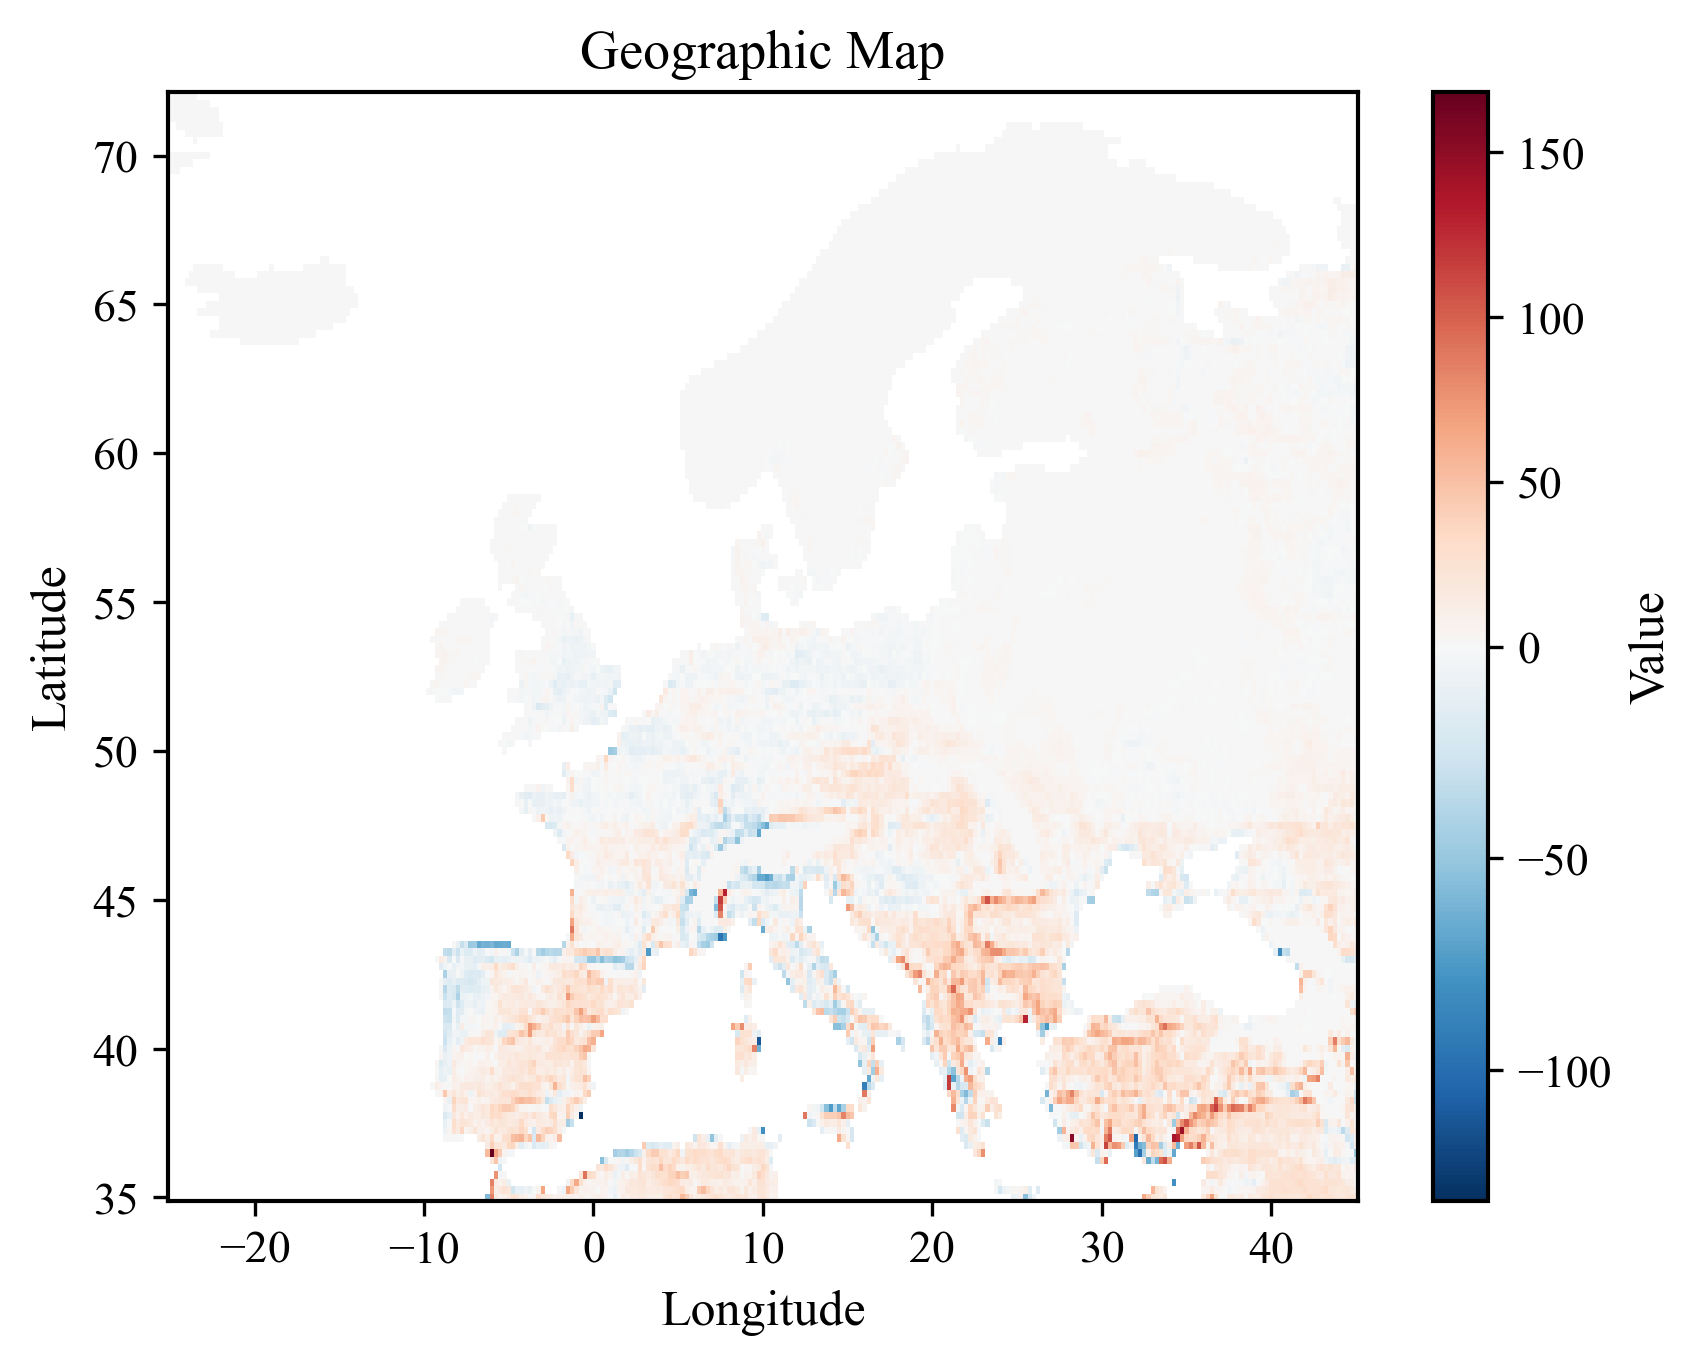

In [ ]:

vmin = np.nanmin(count_diff_h_m)
vmax = np.nanmax(count_diff_h_m)

norm = mcolors.TwoSlopeNorm(
    vmin=vmin,
    vcenter=0,
    vmax=vmax
)

plt.figure()
mesh = plt.pcolormesh(
    lons,
    lats,
    count_diff_h_m,
    shading='auto',
    cmap='RdBu_r',   # good diverging map
    norm=norm
)

plt.colorbar(mesh, label='Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Map')
plt.show()

## PLot Mean and Var

In [ ]:
import matplotlib.dates as mdates

In [ ]:
utci_heat_stress_categories = {
    "Moderate": 26,
    "Strong": 32,
    "Very strong": 38,
    # "Extreme": 46,
}

utci_cold_stress_categories = {
    #"Slight": 9,
    "Moderate": 0,
    "Strong": -13,
    "Very strong": -27,
    # "Extreme": -40,
}

In [ ]:
UTCI_CATEGORIES = {
    'extreme_cold': -40,
    'very_strong_cold': -27,
    'strong_cold': -13,
    'moderate_cold': 0,
    'no_thermal_stress': 9,
    'moderate_heat': 26,
    'strong_heat': 32,
    'very_strong_heat': 38,
    'extreme_heat': 46
}


def get_stress_category(utci_value):
    """Assign UTCI stress category based on value."""
    if utci_value < 0:
        if utci_value < UTCI_CATEGORIES['extreme_cold']:
            return 'Extreme cold stress'
        elif utci_value < UTCI_CATEGORIES['very_strong_cold']:
            return 'Very strong cold stress'
        elif utci_value < UTCI_CATEGORIES['strong_cold']:
            return 'Strong cold stress'
        elif utci_value < UTCI_CATEGORIES['moderate_cold']:
            return 'Moderate cold stress'
        elif utci_value < UTCI_CATEGORIES['no_thermal_stress']:
            return 'Slight cold stress'
        else:
            return 'No thermal stress'
        
    else:
        if utci_value < UTCI_CATEGORIES['no_thermal_stress']:
            return 'No thermal stress'
        elif utci_value < UTCI_CATEGORIES['moderate_heat']:
            return 'Moderate heat stress'
        elif utci_value < UTCI_CATEGORIES['strong_heat']:
            return 'Strong heat stress'
        elif utci_value < UTCI_CATEGORIES['very_strong_heat']:
            return 'Very strong heat stress'
        else:
            return 'Extreme heat stress'


def temp_to_utci_mismatch(df, nn_colname, poly_colname):
    """
    df : a dataset with UTCI temperatures
    nn_colname : name of the df column with the NN UTCI data
    poly_colnames : name of the df column with the Poly UTCI data
    categories: ordered list of tuples (lower_bound, label).
                function returns the label for highest lower_bound <= temp.
    """
    df['DiNapoli_category'] = df[poly_colname].apply(get_stress_category)
    df['NN_category']       = df[nn_colname].apply(get_stress_category)
    df['category_mismatch'] = df['DiNapoli_category'] != df['NN_category']

    # Statistics
    n_mismatches = df['category_mismatch'].sum()
    number_of_days = df['DiNapoli_category'].count()
    percentage_mismatch = n_mismatches/number_of_days *100

    return n_mismatches, percentage_mismatch



def shade_model_mismatch_days_with_stats(
    ax,
    series_nn,
    series_poly,
    aggregation='min',            # 'min' or 'max' for daily reduction
    color='orange',
    alpha=0.12,
    category_func=None,          # optional: pass your get_stress_category function
):
    """
    Shade full calendar days where series_nn and series_poly fall into different UTCI categories.
    Also compute and return statistics: mean_diff, pct_mismatch, spans.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axis to draw axvspan on.
    series_nn : pd.Series
        Timestamped NN UTCI series (DatetimeIndex or index coercible to datetime).
    series_poly : pd.Series
        Timestamped polynomial/DiNapoli UTCI series (DatetimeIndex or index coercible to datetime).
    aggregation : str
        'min' or 'max' — whether to use daily minima or daily maxima for the comparison.
    color : str
        Color used for axvspan shading.
    alpha : float
        Alpha transparency for shading.
    category_func : callable or None
        Function f(utci_value) -> category string. If None, a default cold-category function is used.

    Returns
    -------
    dict with keys:
        'mean_diff' : float (mean of daily (NN - Poly) after aggregation),
        'pct_mismatch' : float (percentage of days with category mismatch),
        'spans' : list of (start_timestamp, end_timestamp) tuples for shaded full-day spans
    """
    if aggregation not in ('min', 'max'):
        raise ValueError("aggregation must be 'min' or 'max'")

    # Default category function (cold thresholds). Replace or pass category_func to use a different one.
    if category_func is None:
        UTCI_CATEGORIES = {
            'extreme_cold': -40,
            'very_strong_cold': -27,
            'strong_cold': -13,
            'moderate_cold': 0,
            'no_thermal_stress': 9,
            'moderate_heat': 26,
            'strong_heat': 32,
            'very_strong_heat': 38,
            'extreme_heat': 46
        }

        def default_get_stress_category(utci_value):
            """Assign UTCI stress category based on value."""
            if utci_value < 0:
                if utci_value < UTCI_CATEGORIES['extreme_cold']:
                    return 'Extreme cold stress'
                elif utci_value < UTCI_CATEGORIES['very_strong_cold']:
                    return 'Very strong cold stress'
                elif utci_value < UTCI_CATEGORIES['strong_cold']:
                    return 'Strong cold stress'
                elif utci_value < UTCI_CATEGORIES['moderate_cold']:
                    return 'Moderate cold stress'
                elif utci_value < UTCI_CATEGORIES['no_thermal_stress']:
                    return 'Slight cold stress'
                else:
                    return 'No thermal stress'
                
            else:
                if utci_value < UTCI_CATEGORIES['no_thermal_stress']:
                    return 'No thermal stress'
                elif utci_value < UTCI_CATEGORIES['moderate_heat']:
                    return 'Moderate heat stress'
                elif utci_value < UTCI_CATEGORIES['strong_heat']:
                    return 'Strong heat stress'
                elif utci_value < UTCI_CATEGORIES['very_strong_heat']:
                    return 'Very strong heat stress'
                else:
                    return 'Extreme heat stress'


        
        category_func = default_get_stress_category

    # Ensure indexes are DateTimeIndex
    if not isinstance(series_nn.index, pd.DatetimeIndex):
        series_nn = series_nn.copy()
        series_nn.index = pd.to_datetime(series_nn.index)
    if not isinstance(series_poly.index, pd.DatetimeIndex):
        series_poly = series_poly.copy()
        series_poly.index = pd.to_datetime(series_poly.index)

    # Align series and drop any timestamps where either is missing
    df = pd.concat([series_nn.rename('nn'), series_poly.rename('poly')], axis=1)
    df = df.dropna(how='any')   # only compare timestamps where both exist
    if df.empty:
        return {'mean_diff': np.nan, 'pct_mismatch': 0.0, 'spans': []}

    # Aggregate to daily minima or maxima
    if aggregation == 'min':
        df_daily = df.resample('D').min()
    else:
        df_daily = df.resample('D').max()

    # Drop days where either aggregated value is NaN (e.g., fully-missing day)
    df_daily = df_daily.dropna(how='any')
    if df_daily.empty:
        return {'mean_diff': np.nan, 'pct_mismatch': 0.0, 'spans': []}

    # Compute categories
    cat_nn_daily = df_daily['nn'].apply(category_func)
    cat_poly_daily = df_daily['poly'].apply(category_func)

    # Build mismatch mask (boolean Series indexed by midnight timestamps)
    mask_daily = (cat_nn_daily != cat_poly_daily) & (~cat_nn_daily.isna()) & (~cat_poly_daily.isna())

    # Statistics
    # mean difference: use daily NN - Poly (aggregated) mean
    mean_diff = (df_daily['nn'] - df_daily['poly']).mean()
    pct_mismatch = 100.0 * mask_daily.sum() / len(df_daily)

    # Shade full calendar days: from midnight to next midnight
    spans = []
    for day_midnight in mask_daily[mask_daily].index:
        start = pd.Timestamp(day_midnight).normalize()          # ensures midnight
        end = start + pd.Timedelta(days=1)
        ax.axvspan(start, end, color=color, alpha=alpha, linewidth=0)
        spans.append((start, end))

    return {'mean_diff': mean_diff, 'pct_mismatch': pct_mismatch, 'spans': spans}



In [ ]:
# =========================
# 4. PREPARE DATA FOR PLOTTING
# =========================
plotting_data = xr.Dataset(
    data_vars={
        'mean_heat': (('lat', 'lon'), mean_heatwave_utci_diff_land),
        'mean_cold': (('lat', 'lon'), mean_coldspell_utci_diff_land),
        'count_diff_heat' : (('lat', 'lon'), avg_count_diff_h),
        'count_diff_cold' : (('lat', 'lon'), avg_count_diff_c),
        # 'var_heat':  (('lat', 'lon'), var_heatwave_utci_diff_land),
        # 'var_cold':  (('lat', 'lon'), var_coldspell_utci_diff_land),
    },
    coords={
        'lon': results_2003_heatwave['lon'].values,
        'lat': results_2003_heatwave['lat'].values,
    }
)

colors = {
    'Polynomial': '#2C048E',  # Blue
    'NN': '#C00D31',  # Red
    'threshold': '#CCCCCC'  # Light gray
}
# -------------------------
# Publication-style settings
# -------------------------
# --- Publication-quality rc settings (consistent + larger text) ---
plt.rcParams.update({
    'figure.dpi': 300,                    # screen DPI (saving overrides with fig.savefig)
    'savefig.dpi': 600,                   # high-res saves
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12,                      # base font size (controls many defaults)
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.frameon': False,
    'lines.linewidth': 1.5,
    'lines.markersize': 6,
    'axes.grid': False,
    'pdf.fonttype': 42, 
    'ps.fonttype': 42,
})


# City coordinates
rome_coords = (41.9028, 12.4964)   # (lat, lon) Rome
warsaw_coords = (52.2297, 21.0122) # (lat, lon) Warsaw

# -------------------------
# Create figure with four panels
# -------------------------

fig = plt.figure(figsize=(9, 11))

gs = fig.add_gridspec(3, 2, height_ratios=[1, 1, 0.8], )

map_crs = ccrs.PlateCarree() 
data_crs = ccrs.PlateCarree()

ax_a = fig.add_subplot(gs[0, 0], projection=map_crs)
ax_b = fig.add_subplot(gs[0, 1], projection=map_crs)

ax_c = fig.add_subplot(gs[1, 0], projection=map_crs)
ax_d = fig.add_subplot(gs[1, 1], projection=map_crs)

# Time-series axes (third row)
ax_e = fig.add_subplot(gs[2, 0])   # Rome (heat)
ax_f = fig.add_subplot(gs[2, 1])   # Warsaw (cold)

# Common map decor function
def add_map_decor(ax):
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4, zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', linewidth=0.5, zorder=2)

# -------------------------
# Panel A: Mean Heat Difference (left)
# -------------------------
add_map_decor(ax_a)
ax_a.set_extent([plotting_data['lon'].min(), plotting_data['lon'].max(), plotting_data['lat'].min(), plotting_data['lat'].max()], crs=map_crs)
ax_a.set_aspect('auto')

levels_left = np.linspace(-4, 4, 11)
norm_left = mcolors.TwoSlopeNorm(
    vmin= -4,
    vcenter=0,
    vmax=4
)

im_a = ax_a.contourf(
    plotting_data['lon'], plotting_data['lat'], plotting_data['mean_heat'],
    levels=levels_left,
    cmap='RdBu_r',
    norm=norm_left,
    extend='both',
    transform=map_crs
)


# -------------------------
# Panel B: Mean Cold Difference (right)
# -------------------------
add_map_decor(ax_b)
ax_b.set_extent([plotting_data['lon'].min(), plotting_data['lon'].max(), plotting_data['lat'].min(), plotting_data['lat'].max()], crs=map_crs)
ax_b.set_aspect('auto')

levels_right = np.linspace(-4, 4, 11)
norm_right = mcolors.TwoSlopeNorm(
    vmin=-4,
    vcenter=0,
    vmax=4
)

im_b = ax_b.contourf(
    plotting_data['lon'], plotting_data['lat'], plotting_data['mean_cold'],
    levels=levels_right,
    cmap='RdBu_r',
    norm=norm_right,
    extend='both',
    transform=map_crs
)

# -------------------------
# Panel C: Heat Exposure Difference (left, bottom)
# -------------------------
add_map_decor(ax_c)
ax_c.set_extent([plotting_data['lon'].min(), plotting_data['lon'].max(), plotting_data['lat'].min(), plotting_data['lat'].max()], crs=map_crs)
ax_c.set_aspect('auto')

levels_left = np.linspace(-2, 2, 11)
norm_left = mcolors.TwoSlopeNorm(
    vmin= -2,
    vcenter=0,
    vmax=2
)

im_c = ax_c.contourf(
    plotting_data['lon'], plotting_data['lat'], plotting_data['count_diff_heat'],
    levels=levels_left,
    cmap='PiYG_r',
    norm=norm_left,
    extend='both',
    transform=map_crs
)


# -------------------------
# Panel D: Cold Exposure Difference (right, bottom)
# -------------------------
add_map_decor(ax_d)
ax_d.set_extent([plotting_data['lon'].min(), plotting_data['lon'].max(), plotting_data['lat'].min(), plotting_data['lat'].max()], crs=map_crs)
ax_d.set_aspect('auto')

leveles_var_right = np.linspace(0, 16, 16)

levels_left = np.linspace(-4, 4, 11)
norm_left = mcolors.TwoSlopeNorm(
    vmin= -4,
    vcenter=0,
    vmax=4
)

im_d = ax_d.contourf(
    plotting_data['lon'], plotting_data['lat'], plotting_data['count_diff_cold'],
    levels=levels_left,
    cmap='PiYG_r',
    norm=norm_left,
    extend='both',
    transform=map_crs
)

# -------------------------
# Add city markers
# -------------------------

marker_city = '*'
marker_size_city = 9
marker_color_city = 'Black'

ax_a.plot(rome_coords[1], rome_coords[0], marker=marker_city, color=marker_color_city, markersize=marker_size_city, transform=map_crs, label='Rome')
ax_b.plot(warsaw_coords[1], warsaw_coords[0], marker=marker_city, color=marker_color_city, markersize=marker_size_city, transform=map_crs, label='Warsaw')
ax_c.plot(rome_coords[1], rome_coords[0], marker=marker_city, color=marker_color_city, markersize=marker_size_city, transform=map_crs, label='Rome')
ax_d.plot(warsaw_coords[1], warsaw_coords[0], marker=marker_city, color=marker_color_city, markersize=marker_size_city, transform=map_crs, label='Warsaw')

# -------------------------
# Panel E: Rome line graph
#--------------------------
df_rome = daily_extreme_temp_city(
    daily_data_NN = results_2003_heatwave['utci_NN'],
    daily_data_Poly = results_2003_heatwave['utci_DiNapoli'],
    city_lat=rome_coords[0],   
    city_lon=rome_coords[1],
    extreme='max'
)
ax_e.plot(df_rome.index, df_rome['utci_NN'], label='Neural-UTCI', color=colors['NN'])
ax_e.plot(df_rome.index, df_rome['utci_Poly'], label='Polynomial-UTCI', color=colors['Polynomial'])

# add thresholds
x_pos = df_rome.index[24]
for label, y in utci_heat_stress_categories.items():
    ax_e.axhline(y=y, linestyle='--', linewidth=1, color='gray', alpha=0.7)
    #ax_e.text(x_pos, y, label, va='bottom', ha='right', fontsize=9, color='gray')

# format x axis
ax_e.set_ylabel("UTCI (°C)")
ax_e.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
#ax_e.tick_params(axis='x', labelrotation=45)

# shade days where NN and Polynomial are in different UTCI categories ---
# Shade mismatches and get stats

shade_model_mismatch_days_with_stats
stats_rome = shade_model_mismatch_days_with_stats(
    ax_e,
    series_nn = df_rome['utci_NN'],
    series_poly = df_rome['utci_Poly'],
    aggregation='max',
    color = colors['threshold'],
    alpha = 0.7
)


rome_hse_hrs = plotting_data['count_diff_heat'].sel(lat=rome_coords[0], lon=rome_coords[1], method='nearest')

# txt_rome = f"Mismatched days: {stats_rome['pct_mismatch']:.1f}%\nMean Δ: {stats_rome['mean_diff']:.2f} °C\nHSE hrs: {rome_hse_hrs:.1f}"
# ax_e.text(0.016, 0.22, txt_rome, transform=ax_e.transAxes, va='top', ha='left',
#           fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))


ax_e.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax_e.tick_params(axis='x', labelrotation=45)

# -------------------------
# Panel F: Warsaw line graph
#--------------------------
# Warsaw - daily maxima
df_warsaw = daily_extreme_temp_city(
    daily_data_NN = results_2012_coldspell['utci_NN'],
    daily_data_Poly = results_2012_coldspell['utci_DiNapoli'],
    city_lat=warsaw_coords[0],   
    city_lon=warsaw_coords[1],
    extreme='min'
)
ax_f.plot(df_warsaw.index, df_warsaw['utci_NN'], label='Neural-UTCI', color=colors['NN'])
ax_f.plot(df_warsaw.index, df_warsaw['utci_Poly'], label='Polynomial-UTCI', color=colors['Polynomial'])

# add thresholds
x_pos = df_warsaw.index[24]
for label, y in utci_cold_stress_categories.items():
    ax_f.axhline(y=y, linestyle='--', linewidth=1, color='gray', alpha=0.7)
    #ax_f.text(x_pos, y, label, va='bottom', ha='right', fontsize=9, color='gray')

# format x axis
ax_f.set_ylabel("UTCI (°C)")
ax_f.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax_f.tick_params(axis='x', labelrotation=45)

# shade days where NN and Polynomial are in different UTCI categories ---
stats_warsaw = shade_model_mismatch_days_with_stats(
    ax_f,
    series_nn = df_warsaw['utci_NN'],
    series_poly = df_warsaw['utci_Poly'],
    aggregation='min',
    color = colors['threshold'],
    alpha = 0.7
)

warsaw_cse_hrs = plotting_data['count_diff_heat'].sel(lat=warsaw_coords[0], lon=warsaw_coords[1], method='nearest')

# txt_warsaw = f"Mismatched days: {stats_warsaw['pct_mismatch']:.1f}%\nMean Δ: {stats_warsaw['mean_diff']:.2f} °C\nCSE hrs: {warsaw_cse_hrs:.1f}"
# ax_f.text(0.016, 0.22, txt_warsaw, transform=ax_f.transAxes, va='top', ha='left',
#           fontsize=8, bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax_f.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
ax_f.tick_params(axis='x', labelrotation=45)

# -------------------------
# Add pannel labels 
# -------------------------
panel_labels = ['a', 'b', 'c','d', 'e', 'f']
for idx, ax in enumerate([ax_a, ax_b, ax_c, ax_d, ax_e, ax_f]):
    ax.text(-0.08, 1.07, panel_labels[idx], transform=ax.transAxes,
            fontsize=13, fontweight='bold', va='top', ha='left')
    
# ------------------------
# Add pannel Titles
# ------------------------
ax_a.set_title(f"2003 Heatwave",fontsize=13, fontweight='bold', pad=8)
ax_b.set_title(f"2012 Cold Spell",fontsize=13,  fontweight='bold', pad=8)
# ax_c.set_title(f"2003 Heatwave",fontsize=11, fontweight='bold', pad=8)
# ax_d.set_title(f"2012 Coldspell",fontsize=11,  fontweight='bold', pad=8)

# ------------------------
# Add Colourbar
# ------------------------

cbar_a = fig.colorbar(im_a, ax=ax_a, orientation='horizontal', pad=0.05, fraction=0.05, shrink= 1.5)
cbar_a.set_label(f"Mean UTCI difference (°C)", fontsize=9) 
cbar_a.ax.tick_params(labelsize=8)

cbar_b = fig.colorbar(im_b, ax=ax_b, orientation='horizontal', pad=0.05, fraction=0.05, shrink= 1.0)
cbar_b.set_label(f"Mean UTCI difference (°C)", fontsize=9)
cbar_b.ax.tick_params(labelsize=8)

cbar_c = fig.colorbar(im_c, ax=ax_c, orientation='horizontal', pad=0.05, fraction=0.05, shrink=1.0)
cbar_c.set_label(f"Difference in mean daily heat stress exposure (hours)", fontsize=9)
cbar_c.ax.tick_params(labelsize=8)

cbar_d = fig.colorbar(im_d, ax=ax_d, orientation='horizontal', pad=0.05, fraction=0.05, shrink=1.0)
cbar_d.set_label(f"Difference in mean daily cold stress exposure (hours)", fontsize=9)
cbar_d.ax.tick_params(labelsize=8)


# Adjust bbox_to_anchor and y coordinate to taste (here: just below axes)
fig = ax_e.get_figure()
handles_e, labels_e = ax_e.get_legend_handles_labels()
fig.legend(handles_e, labels_e, loc='lower center', ncol=len(labels_e),
           bbox_to_anchor=(0.5, -0.04), frameon=False)

# Tight layout so legend doesn't overlap - adjust bottom margin to fit the legend
plt.tight_layout()
#fig.subplots_adjust(bottom=0.18)  # increase if legend overlaps; tweak as needed

# -------------------------
# Final layout and save
# -------------------------

out_base = "C:\\Users\\nerc-user\\OneDrive - Nexus365\\UTCI_NN\\Main\\figures\\main_text\\final\\figure4_extreme_event"
#fig.savefig(out_base + ".pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Figure saved as {out_base}.png (600 dpi raster)")

NameError: name 'mean_heatwave_utci_diff_land' is not defined

## Plotting

In [15]:
import matplotlib.colors as mcolors

In [29]:
def percentile_limits(data, pmin=10, pmax=90):
    vals = np.asarray(data)[np.isfinite(data)]
    if vals.size == 0:
        return -1, 1
    return np.percentile(vals, [pmin, pmax])

## Cold spell

In [30]:

# =========================
# 2. HELPER FUNCTION: COUNT HOURS BELOW THRESHOLD
# =========================

def count_hours_below_threshold(arr, threshold=-13.0, time_dim='time'):
    """
    Count hours below a given UTCI threshold.
    
    Parameters
    ----------
    arr : xarray.DataArray or numpy.ndarray
        3D array (time, lat, lon)
    threshold : float
        UTCI threshold in °C
    time_dim : str
        Name of time dimension in xarray array
    
    Returns
    -------
    2D numpy.ndarray (lat, lon) with counts of hours below threshold
    """
    import xarray as xr

    if isinstance(arr, (xr.DataArray, xr.Dataset)):
        if isinstance(arr, xr.Dataset):
            arr = list(arr.data_vars.values())[0]
        counts = (arr < threshold).sum(dim=time_dim, skipna=True)
        return counts.values.astype(np.float64)
    else:
        a = np.asarray(arr)
        if a.ndim != 3:
            raise ValueError(f"Expected 3D array, got shape {a.shape}")
        return np.sum(a < threshold, axis=0).astype(np.float64)

# =========================
# 3. PREPARE DATA FOR TWO PANELS
# =========================

# Panel A: Mean UTCI Difference
lon_a = results_2012_day_land['lon'].values
lat_a = results_2012_day_land['lat'].values
data_a = mean_utci_diff_land  # 2D array

# Panel B: Cold Stress Hours Difference
utci_nn = results_2012_day_land['utci_NN'].where(land_mask)
utci_dn = results_2012_day_land['utci_DiNapoli'].where(land_mask)

# Longitude and latitude
lon_b = utci_nn['lon'].values
lat_b = utci_nn['lat'].values

# Compute counts below threshold
threshold = -13.0
count_nn = count_hours_below_threshold(utci_nn, threshold=threshold)
count_dn = count_hours_below_threshold(utci_dn, threshold=threshold)

# Percentage difference
count_diff = count_nn - count_dn

# Mask invalid or zero-difference cells
both_nan = np.isnan(count_nn) & np.isnan(count_dn)
count_diff = np.where(both_nan, np.nan, count_diff)
count_diff = np.where(np.isfinite(count_diff), count_diff, np.nan)

data_b = np.where(land_mask, count_diff, np.nan)/60 # Convert to hours per day, 60 days in the period

# Ensure data shape matches lat/lon
if data_b.shape != (len(lat_b), len(lon_b)):
    if data_b.shape == (len(lon_b), len(lat_b)):
        data_b = data_b.T

# =========================
# 4. PUBLICATION-STYLE SETTINGS
# =========================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "axes.linewidth": 0.6,
})

# =========================
# 5. CREATE FIGURE WITH TWO PANELS
# =========================

fig = plt.figure(figsize=(14, 5.5))
proj = ccrs.PlateCarree()

ax_a = fig.add_subplot(1, 2, 1, projection=proj)
ax_b = fig.add_subplot(1, 2, 2, projection=proj)

# -------------------------
# Panel A: Mean UTCI Difference
# -------------------------

# Map decorations
for ax in [ax_a]:
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4, zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', linewidth=0.5, zorder=2)

ax_a.set_extent([lon_a.min(), lon_a.max(), lat_a.min(), lat_a.max()], crs=proj)

gl_a = ax_a.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.4, linestyle='--', color='gray', alpha=0.6)
gl_a.top_labels = False
gl_a.right_labels = False
gl_a.left_labels = True
gl_a.bottom_labels = True
gl_a.xlabel_style = {"size": 8}
gl_a.ylabel_style = {"size": 8}

vmax_a = np.nanmax(np.abs(data_a)) or 1e-6
levels_a = np.linspace(-vmax_a, vmax_a, 11)
im_a = ax_a.contourf(lon_a, lat_a, data_a, levels=levels_a, cmap='RdBu_r',
                     extend='both', transform=proj, antialiased=True)

ax_a.set_title("Mean UTCI Difference — 2012 Coldspell", fontsize=11, fontweight='bold', pad=8)
ax_a.text(-0.04, 1.05, "A", transform=ax_a.transAxes, fontsize=14, fontweight='bold',
          va='top', ha='left', bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none", alpha=0.9))

cbar_a = fig.colorbar(im_a, ax=ax_a, orientation='horizontal', pad=0.05, fraction=0.05, shrink=0.85)
cbar_a.set_label("Mean UTCI Difference: NN − Poly (°C)", fontsize=9)
cbar_a.ax.tick_params(labelsize=8)

# -------------------------
# Panel B: Cold Stress Hours % Difference
# -------------------------

# Set map extent
ax_b.set_extent([lon_b.min(), lon_b.max(), lat_b.min(), lat_b.max()], crs=proj)

# Gridlines
gl_b = ax_b.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.4, linestyle='--', color='gray', alpha=0.6)
gl_b.top_labels = False
gl_b.right_labels = True
gl_b.left_labels = False
gl_b.bottom_labels = True
gl_b.xlabel_style = {"size": 8}
gl_b.ylabel_style = {"size": 8}


# Set symmetric range and partitions

vmin, vmax = -3, 3
num_levels = 21  # number of partitions

# Generate 21 equally spaced levels between -120 and 120
levels = np.linspace(vmin, vmax, num_levels)

# Diverging colormap normalized around 0
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = 'PiYG'


# Plot
im_b = ax_b.contourf(
    lon_b, lat_b, data_b,
    levels=levels,  # 21 partitions
    cmap=cmap,
    norm=norm,
    extend='both',
    transform=proj
)

# Map decorations
for ax in [ax_b]:
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4, zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', linewidth=0.5, zorder=2)

# Title and panel label
ax_b.set_title("Cold Stress Hours Difference per Day — 2012 Coldspell", fontsize=11, fontweight='bold', pad=8)
ax_b.text(-0.04, 1.05, "B", transform=ax_b.transAxes, fontsize=14, fontweight='bold',
          va='top', ha='left', bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none", alpha=0.9))

# Colorbar
cbar_b = fig.colorbar(im_b, ax=ax_b, orientation='horizontal', pad=0.05, fraction=0.05, shrink=0.85)
cbar_b.set_label("Cold Stress Hours Difference: (NN − Poly)", fontsize=9)
cbar_b.ax.tick_params(labelsize=8)

# =========================
# 6. FINAL LAYOUT AND SAVE
# =========================

plt.tight_layout()

out_base = "two_panel_map_comparison_2012"
fig.savefig(out_base + ".pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Figure saved as {out_base}.pdf (vector) and {out_base}.png (600 dpi raster)")


NameError: name 'results_2012_day_land' is not defined

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, DayLocator
import xarray as xr

# ------------------------
# 1. Daily minimum UTCI for DiNapoli and NN
# ------------------------
daily_min_dinapoli = results_2012_day_land['utci_DiNapoli'].groupby('time.date').min(dim='time', skipna=True)
daily_min_NN      = results_2012_day_land['utci_NN'].groupby('time.date').min(dim='time', skipna=True)

# ------------------------
# 2. UTCI stress categories (cold stress thresholds in °C)
# ------------------------
UTCI_CATEGORIES = {
    'extreme_cold': -40,
    'very_strong_cold': -27,
    'strong_cold': -13,
    'moderate_cold': 0,
    'no_thermal_stress': 9
}

def get_stress_category(utci_value):
    """Assign UTCI stress category based on value."""
    if utci_value < UTCI_CATEGORIES['extreme_cold']:
        return 'Extreme cold stress'
    elif utci_value < UTCI_CATEGORIES['very_strong_cold']:
        return 'Very strong cold stress'
    elif utci_value < UTCI_CATEGORIES['strong_cold']:
        return 'Strong cold stress'
    elif utci_value < UTCI_CATEGORIES['moderate_cold']:
        return 'Moderate cold stress'
    elif utci_value < UTCI_CATEGORIES['no_thermal_stress']:
        return 'Slight cold stress'
    else:
        return 'No thermal stress'



def extract_city_timeseries(data, lat, lon):
    """Extract time series for nearest grid point to city coordinates."""
    return data.sel(lat=lat, lon=lon, method='nearest')

# ------------------------
# 3. City coordinates
# ------------------------
cities = {
    "Kyiv": (50.4501, 30.5234),
    "Warsaw": (52.2297, 21.0122),
    "Bucharest": (44.4268, 26.1025),
    "Kuusamo": (65.9667, 29.1833)
}

# ------------------------
# 4. Plotting color palette
# ------------------------
colors = {
    'DiNapoli': '#2C048E',  # purple/blue
    'NN': '#C00D31',        # red
    'threshold': '#CCCCCC', # light gray for UTCI thresholds
    'mismatch_span': '#FFE5E5'  # highlight for category mismatches
}

# ------------------------
# 5. Create 2x2 figure
# ------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (city, (lat, lon)) in zip(axes, cities.items()):
    try:
        # Extract nearest-gridpoint time series
        dinapoli_ts = extract_city_timeseries(daily_min_dinapoli, lat, lon)
        nn_ts       = extract_city_timeseries(daily_min_NN, lat, lon)

        # Build DataFrame for easier processing
        dates = pd.to_datetime(dinapoli_ts.date.values) if 'date' in dinapoli_ts.coords else pd.to_datetime(dinapoli_ts.time.values)
        df = pd.DataFrame({
            'date': dates,
            'DiNapoli': dinapoli_ts.values.ravel(),
            'NN': nn_ts.values.ravel()
        })

        # Diagnostics
        df['difference'] = df['NN'] - df['DiNapoli']
        df['DiNapoli_category'] = df['DiNapoli'].apply(get_stress_category)
        df['NN_category']       = df['NN'].apply(get_stress_category)
        df['category_mismatch'] = df['DiNapoli_category'] != df['NN_category']

        # Statistics
        n_mismatches = df['category_mismatch'].sum()
        mismatch_pct = 100.0 * n_mismatches / len(df) if len(df) > 0 else 0.0
        mean_diff = df['difference'].mean() if len(df) > 0 else np.nan
        mae = np.abs(df['difference']).mean() if len(df) > 0 else np.nan

        # Highlight mismatch days
        for _, row in df[df['category_mismatch']].iterrows():
            ax.axvspan(row['date'], row['date'] + pd.Timedelta(days=1),
                       alpha=0.4, color=colors['mismatch_span'], zorder=0)

        # Plot time series
        ax.plot(df['date'], df['DiNapoli'], label='DiNapoli (Polynomial)',
                color=colors['DiNapoli'], linewidth=1.5, zorder=3)
        ax.plot(df['date'], df['NN'], label='Neural Network',
                color=colors['NN'], linewidth=1.5, zorder=3)

        # UTCI horizontal thresholds
        for name, val in UTCI_CATEGORIES.items():
            if name != 'no_thermal_stress':
                ax.axhline(y=val, color=colors['threshold'], linestyle='--', linewidth=0.8, alpha=0.6, zorder=1)

        # Titles, labels, grid
        ax.set_title(f'{city} ({lat:.4f}, {lon:.4f})', fontsize=11, fontweight='bold', loc='left', pad=8)
        ax.set_ylabel('UTCI (°C)', fontsize=10)
        ax.grid(True, alpha=0.25, linestyle='-', linewidth=0.5)
        ax.set_axisbelow(True)

        # X-axis formatting
        ax.xaxis.set_major_locator(DayLocator(interval=max(1, len(df)//10)))
        ax.xaxis.set_major_formatter(DateFormatter('%d %b'))
        ax.tick_params(axis='both', labelsize=9)

        # Y-limits with padding
        if len(df) > 0:
            y_min = df[['DiNapoli', 'NN']].min().min() - 3
            y_max = df[['DiNapoli', 'NN']].max().max() + 3
            ax.set_ylim(y_min, y_max)

        # Legend
        ax.legend(loc='upper right', frameon=True, fontsize=8, edgecolor='black', framealpha=1, fancybox=False)

        # Stats box
        stats_text = f"Mean Δ: {mean_diff:.2f}°C\nMAE: {mae:.2f}°C\n"
        stats_text += f"Mismatch: {mismatch_pct:.1f}% ({n_mismatches}/{len(df)} days)"
        ax.text(0.02, 0.98, stats_text, transform=ax.transAxes,
                fontsize=8, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='black', linewidth=0.6))

    except Exception as e:
        # Handle errors gracefully
        ax.text(0.5, 0.5, f'Error processing {city}:\n{e}',
                ha='center', va='center', fontsize=10, color='red')
        ax.set_title(city, fontsize=11, fontweight='bold', loc='left')
        ax.set_axis_off()

# X-axis label for bottom row
for ax in axes[-2:]:
    ax.set_xlabel('Date', fontsize=10)

plt.tight_layout(h_pad=1.0, w_pad=1.0)

# ------------------------
# 6. Save figures
# ------------------------
plt.savefig('cities_utci_comparison_2x2.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.savefig('cities_utci_comparison_2x2.pdf', bbox_inches='tight', facecolor='white')
plt.savefig('cities_utci_comparison_2x2.eps', format='eps', bbox_inches='tight', facecolor='white')

print("\nSaved plots:")
print(" - cities_utci_comparison_2x2.png (600 dpi)")
print(" - cities_utci_comparison_2x2.pdf")
print(" - cities_utci_comparison_2x2.eps")

plt.show()


NameError: name 'results_2012_day_land' is not defined

### Heat Stress

In [20]:
# =========================
# 1. Load MRT and DiNapoli UTCI data
# =========================
mrt_files = sorted(glob.glob(r"..\data\2003_heatwave\utci_era5\ECMWF_mrt*.nc"))
mrt = xr.open_mfdataset(mrt_files, combine='by_coords', engine='netcdf4')
mrt['mrt_C'] = mrt['mrt'] - 273.15

utci_files = sorted(glob.glob(r"..\data\2003_heatwave\utci_era5\ECMWF_utci*.nc"))
utci_dinapoli = xr.open_mfdataset(utci_files, combine='by_coords', engine='netcdf4')
utci_dinapoli['utci_C'] = utci_dinapoli['utci'] - 273.15

# %%
# =========================
# 2. Load ERA5 environmental variables
# =========================
data_dir = Path("../data/2003_heatwave/input_era5/")
variables = ['u10', 'v10', 'd2m', 't2m']
era5_env = {}

for var in variables:
    files = sorted(glob.glob(str(data_dir / f"{var}_*.nc")))
    if files:
        era5_env[var] = xr.open_mfdataset(files, combine='by_coords', parallel=True, chunks={'time': 100})
        print(f"{var} loaded: {era5_env[var][var].shape}")

# %%
# =========================
# 3. Preprocess: wind speed, RH, etc.
# =========================
def compute_RH_from_Td_T(d2m_celsius, t2m_celsius):
    es_td = np.exp((17.625 * d2m_celsius) / (243.04 + d2m_celsius))
    es_t = np.exp((17.625 * t2m_celsius) / (243.04 + t2m_celsius))
    return 100 * (es_td / es_t)

input_2003 = mrt.copy()
input_2003['t2m_C'] = era5_env['t2m']['t2m'] - 273.15
u10 = era5_env['u10']['u10']
v10 = era5_env['v10']['v10']
input_2003['wind_speed_10m'] = np.sqrt(u10**2 + v10**2)
Td = era5_env['d2m']['d2m'] - 273.15
input_2003['rH'] = (input_2003['t2m_C'].dims, compute_RH_from_Td_T(Td, input_2003['t2m_C']).data)

# %%
# =========================
# 4. Predict UTCI using NN
# =========================
utci_NN_values = predictor.predict(
    Ta=input_2003['t2m_C'],
    Tr=input_2003['mrt_C'],
    va=input_2003['wind_speed_10m'],
    rH=input_2003['rH']
)

utci_NN = xr.DataArray(
    utci_NN_values,
    coords={"time": utci_dinapoli["time"], "lat": utci_dinapoli["lat"], "lon": utci_dinapoli["lon"]},
    dims=("time", "lat", "lon"),
    name="utci_NN"
)
utci_NN = xr.Dataset({"utci_NN": utci_NN})

# Compute NN − DiNapoli difference
utci_diff = utci_NN['utci_NN'] - utci_dinapoli['utci_C']

# %%
# =========================
# 5. Daily maxima & alignment
# =========================
# Daytime mask optional for heat (here we can use full days)
daily_max_dinapoli = utci_dinapoli['utci_C'].groupby('time.date').max(dim='time', skipna=True)
daily_max_NN = utci_NN['utci_NN'].groupby('time.date').max(dim='time', skipna=True)
daily_max_diff = daily_max_NN - daily_max_dinapoli


u10 loaded: (2928, 149, 281)
v10 loaded: (2928, 149, 281)
d2m loaded: (2928, 149, 281)
t2m loaded: (2928, 149, 281)


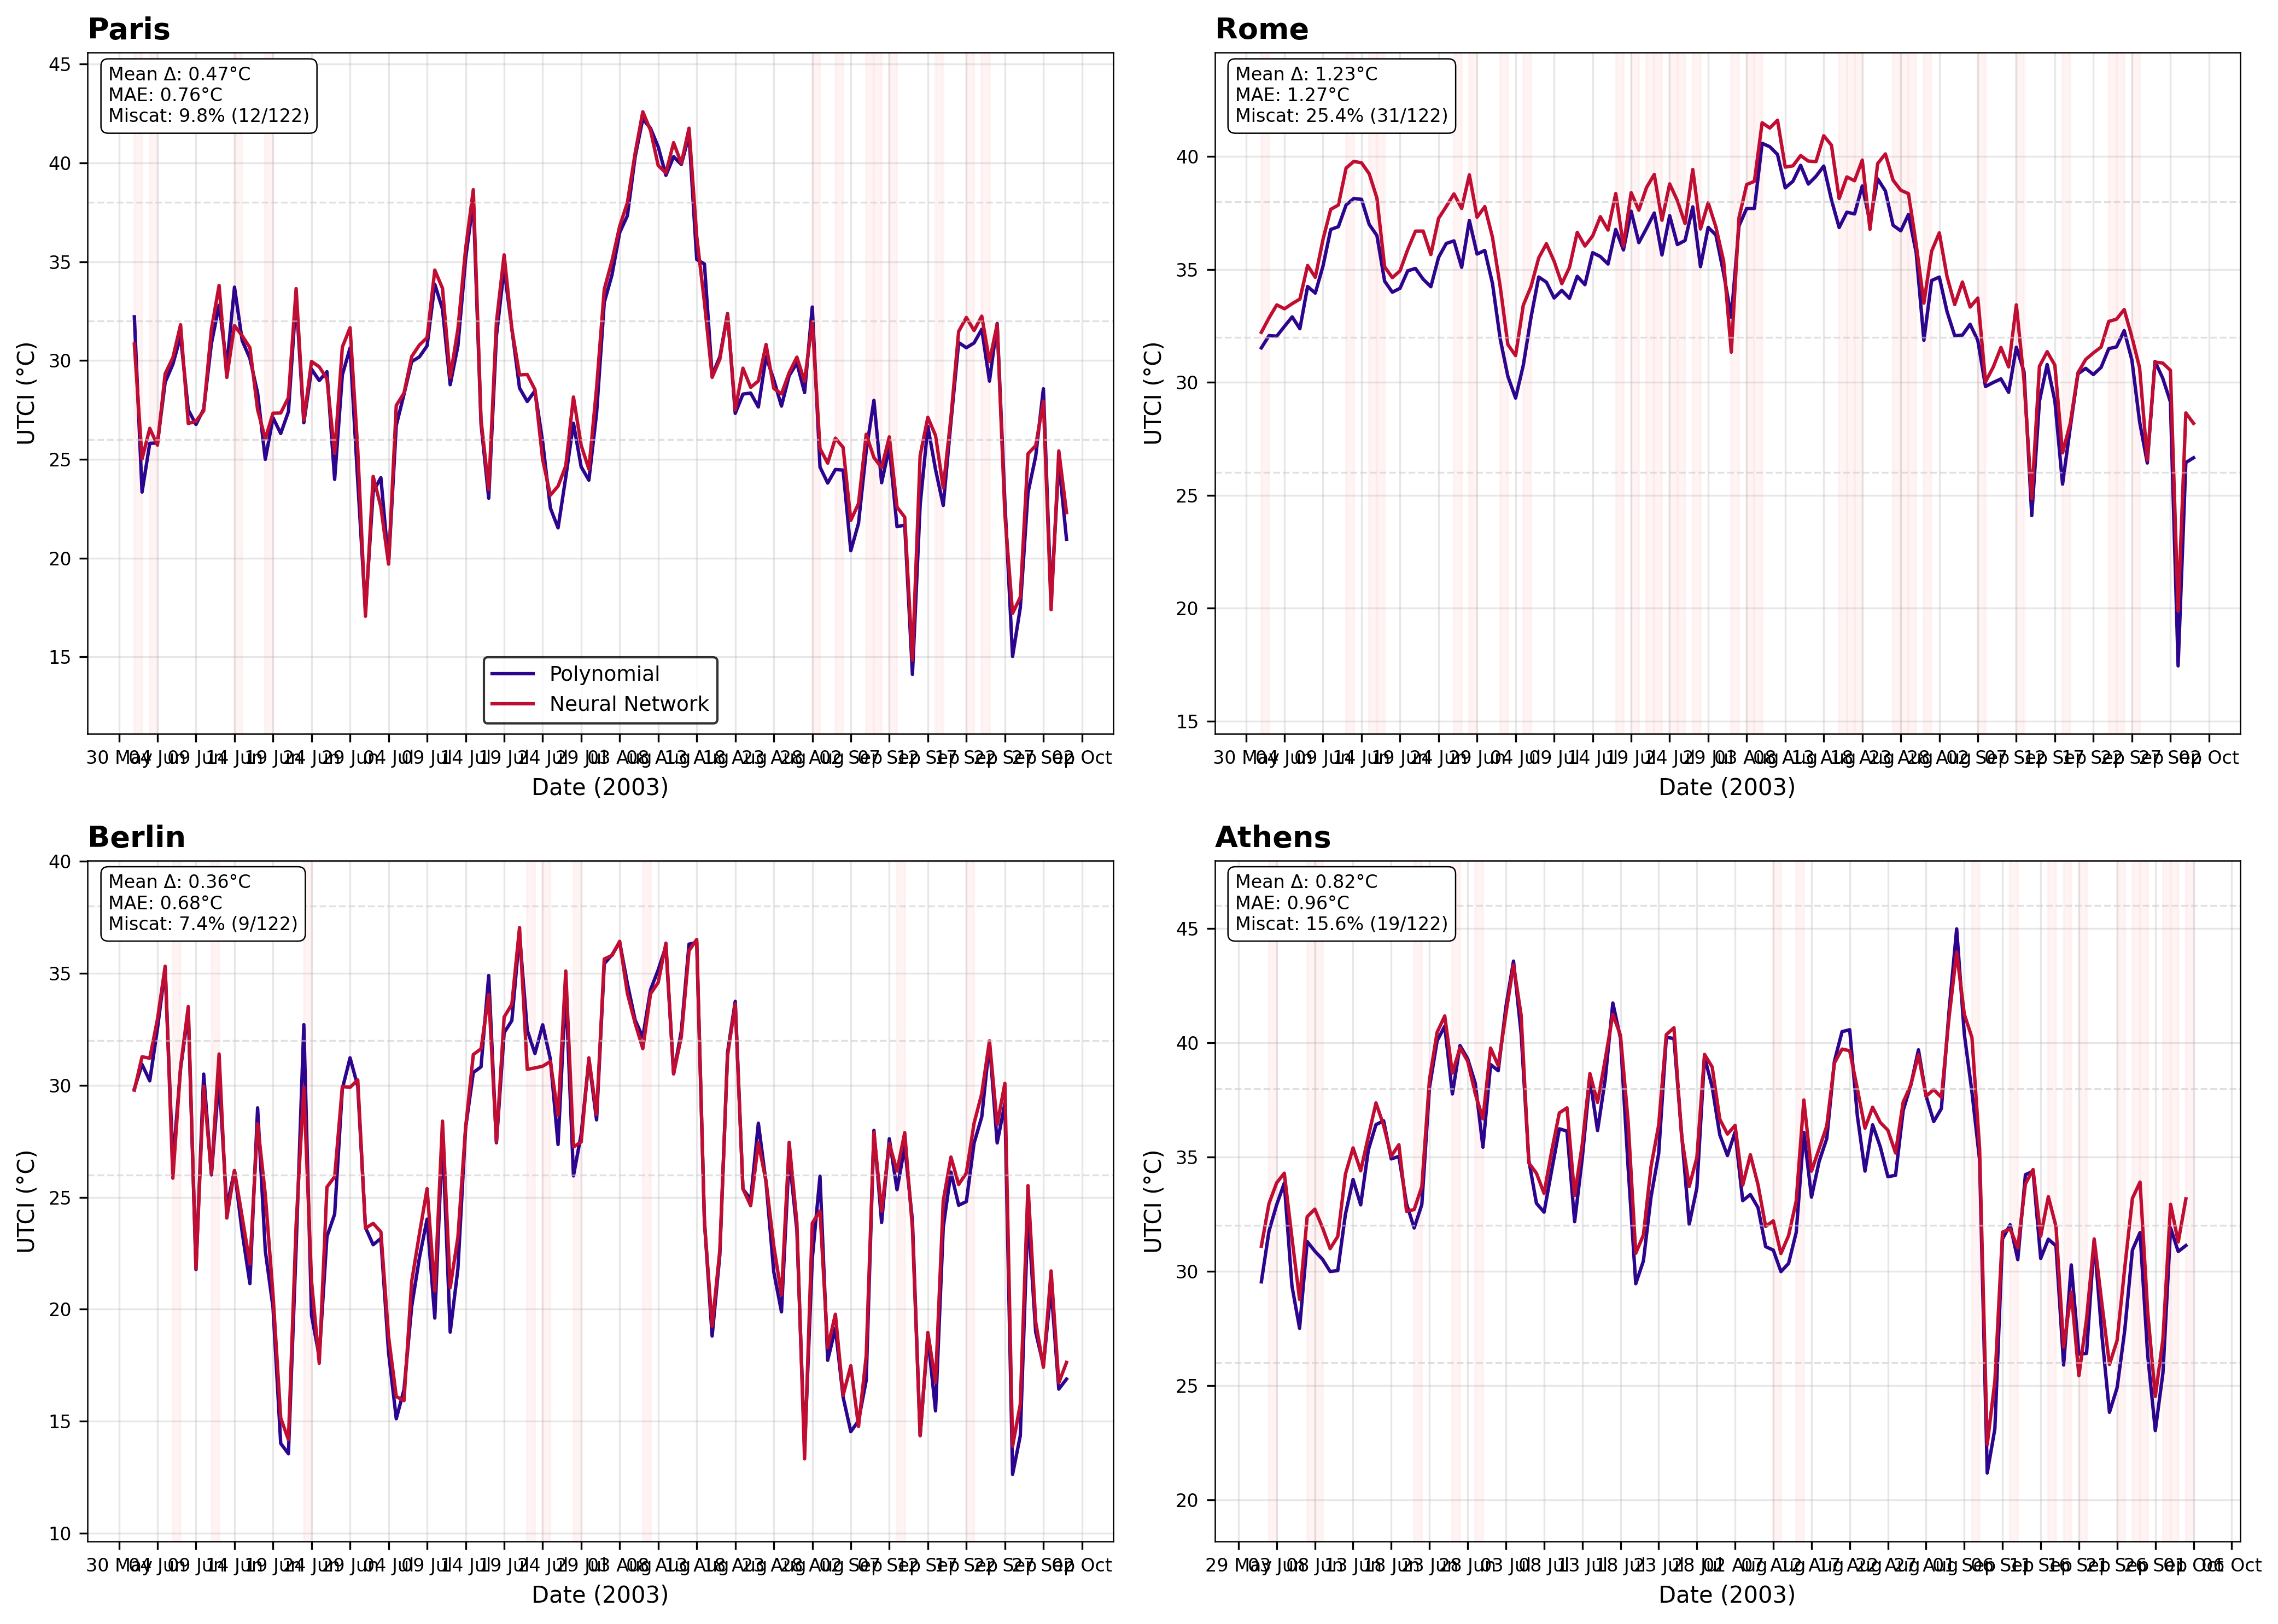

In [21]:

# %%
# =========================
# 6. Heat stress categories
# =========================
UTCI_CATEGORIES = {
    'no_thermal_stress': 9,
    'moderate_heat': 26,
    'strong_heat': 32,
    'very_strong_heat': 38,
    'extreme_heat': 46
}

def get_stress_category(utci_value):
    if utci_value < UTCI_CATEGORIES['no_thermal_stress']:
        return 'No thermal stress'
    elif utci_value < UTCI_CATEGORIES['moderate_heat']:
        return 'Moderate heat stress'
    elif utci_value < UTCI_CATEGORIES['strong_heat']:
        return 'Strong heat stress'
    elif utci_value < UTCI_CATEGORIES['very_strong_heat']:
        return 'Very strong heat stress'
    else:
        return 'Extreme heat stress'

def extract_city_timeseries(data, lat, lon):
    return data.sel(lat=lat, lon=lon, method='nearest')

def compare_categories(utci1, utci2):
    return get_stress_category(utci1) != get_stress_category(utci2)

# %%
# =========================
# 7. Plot cities 2x2
# =========================
cities = {
    "Paris": (48.8566, 2.3522),
    "Rome": (41.9028, 12.4964),
    "Berlin": (52.5200, 13.4050),
    "Athens": (37.9838, 23.7275)
}

colors = {'Polynomial': '#2C048E', 'NN': '#C00D31', 'threshold': '#CCCCCC'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes_flat = axes.flat

for i, (city, (lat, lon)) in enumerate(cities.items()):
    ax = axes_flat[i]
    dinapoli_ts = extract_city_timeseries(daily_max_dinapoli, lat, lon)
    nn_ts = extract_city_timeseries(daily_max_NN, lat, lon)
    dates = pd.to_datetime(dinapoli_ts.date.values)
    df = pd.DataFrame({'date': dates, 'DiNapoli': dinapoli_ts.values, 'NN': nn_ts.values})
    df['difference'] = df['NN'] - df['DiNapoli']
    df['category_mismatch'] = df.apply(lambda r: compare_categories(r['DiNapoli'], r['NN']), axis=1)
    n_mismatches = df['category_mismatch'].sum()
    mismatch_pct = 100 * n_mismatches / len(df)
    mean_diff = df['difference'].mean()
    mae = np.abs(df['difference']).mean()

    for _, row in df[df['category_mismatch']].iterrows():
        ax.axvspan(row['date'], row['date'] + pd.Timedelta(days=1), alpha=0.4, color='#FFE5E5', zorder=0)
    ax.plot(df['date'], df['DiNapoli'], label='Polynomial', color=colors['Polynomial'], linewidth=1.5)
    ax.plot(df['date'], df['NN'], label='Neural Network', color=colors['NN'], linewidth=1.5)

    for _, value in UTCI_CATEGORIES.items():
        ax.axhline(y=value, color=colors['threshold'], linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_title(city, fontsize=13, fontweight='bold', loc='left')
    ax.set_xlabel("Date (2003)", fontsize=10)
    ax.set_ylabel("UTCI (°C)", fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.xaxis.set_major_locator(DayLocator(interval=5))
    ax.xaxis.set_major_formatter(DateFormatter("%d %b"))
    y_min = df[['DiNapoli', 'NN']].min().min() - 3
    y_max = df[['DiNapoli', 'NN']].max().max() + 3
    ax.set_ylim(y_min, y_max)
    textstr = f"Mean Δ: {mean_diff:.2f}°C\nMAE: {mae:.2f}°C\nMiscat: {mismatch_pct:.1f}% ({n_mismatches}/{len(df)})"
    props = dict(boxstyle='round,pad=0.4', facecolor='white', alpha=1.0, edgecolor='black', linewidth=0.6)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=8, verticalalignment='top', bbox=props)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.6)

axes_flat[0].legend(frameon=True, fontsize=9, edgecolor='black')
plt.tight_layout()
plt.show()


In [ ]:
np.nanmax(count_nn)

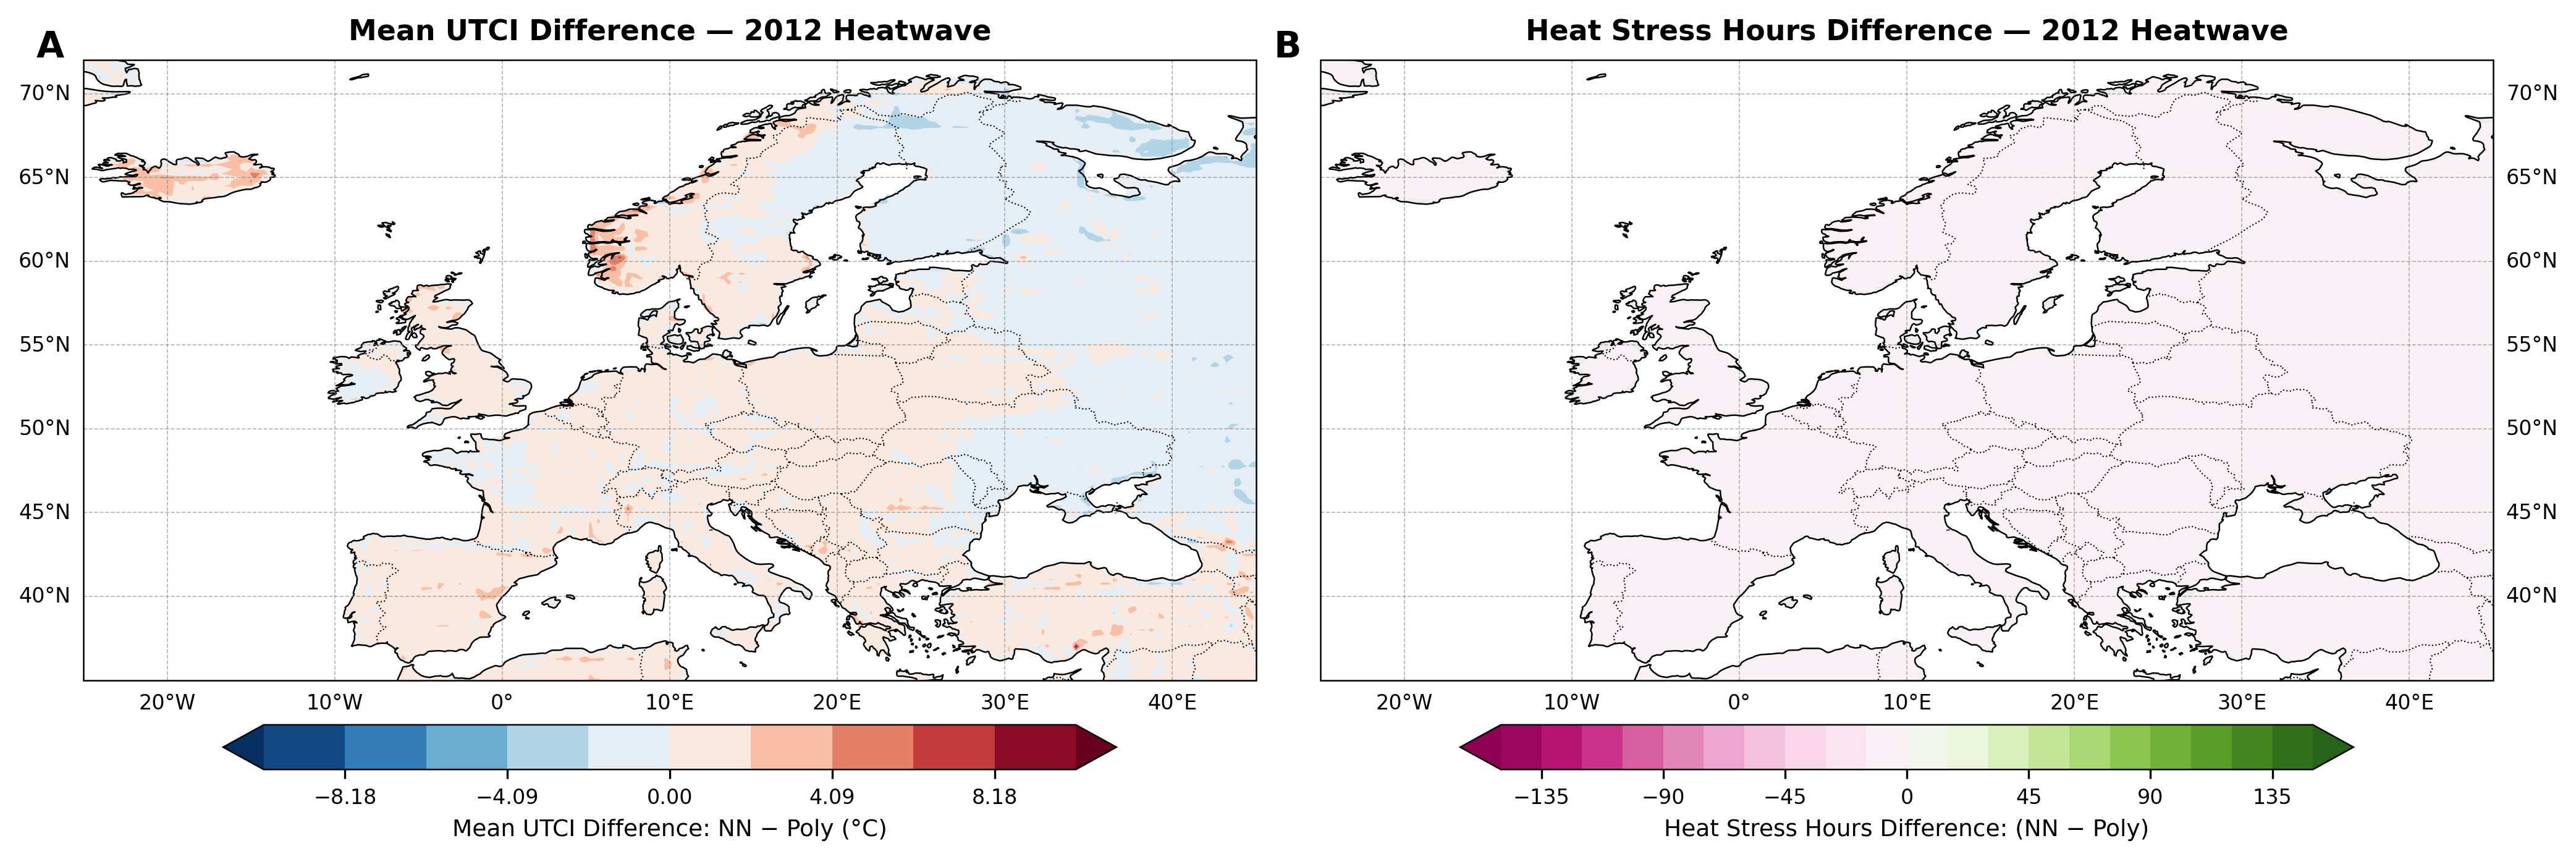

Figure saved as two_panel_map_comparison_2012_heat.pdf (vector) and two_panel_map_comparison_2012_heat.png (600 dpi raster)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# =========================
# HELPER FUNCTION: COUNT HOURS ABOVE THRESHOLD
# =========================

def count_hours_above_threshold(arr, threshold=32.0, time_dim='time'):
    """
    Count hours above a given UTCI threshold.

    Parameters
    ----------
    arr : xarray.DataArray or numpy.ndarray
        3D array (time, lat, lon)
    threshold : float
        UTCI threshold in °C
    time_dim : str
        Name of time dimension in xarray array

    Returns
    -------
    2D numpy.ndarray (lat, lon) with counts of hours above threshold
    """
    import xarray as xr

    if isinstance(arr, (xr.DataArray, xr.Dataset)):
        if isinstance(arr, xr.Dataset):
            arr = list(arr.data_vars.values())[0]
        counts = (arr > threshold).sum(dim=time_dim, skipna=True)
        return counts.values.astype(np.float64)
    else:
        a = np.asarray(arr)
        if a.ndim != 3:
            raise ValueError(f"Expected 3D array, got shape {a.shape}")
        return np.sum(a > threshold, axis=0).astype(np.float64)

# =========================
# PREPARE DATA
# =========================

# Panel A: Mean UTCI Difference
lon_a = results_2012_day_land['lon'].values
lat_a = results_2012_day_land['lat'].values
data_a = mean_utci_diff_land  # 2D array of NN - Poly

# Panel B: Heat Stress Hours Difference
utci_nn = results_2012_day_land['utci_NN'].where(land_mask)
utci_dn = results_2012_day_land['utci_DiNapoli'].where(land_mask)

lon_b = utci_nn['lon'].values
lat_b = utci_nn['lat'].values

# Compute hours above 32°C
count_nn = count_hours_above_threshold(utci_nn, threshold=32.0)
count_dn = count_hours_above_threshold(utci_dn, threshold=32.0)

# Difference
count_diff = count_nn - count_dn

# Mask invalid cells
both_nan = np.isnan(count_nn) & np.isnan(count_dn)
count_diff = np.where(both_nan, np.nan, count_diff)
count_diff = np.where(np.isfinite(count_diff), count_diff, np.nan)
data_b = np.where(land_mask, count_diff, np.nan)

# Ensure shape matches lat/lon
if data_b.shape != (len(lat_b), len(lon_b)):
    if data_b.shape == (len(lon_b), len(lat_b)):
        data_b = data_b.T

# =========================
# PUBLICATION-STYLE SETTINGS
# =========================

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Helvetica", "Arial"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 300,
    "axes.linewidth": 0.6,
})

# =========================
# CREATE FIGURE WITH TWO PANELS
# =========================

fig = plt.figure(figsize=(14, 5.5))
proj = ccrs.PlateCarree()

ax_a = fig.add_subplot(1, 2, 1, projection=proj)
ax_b = fig.add_subplot(1, 2, 2, projection=proj)

# -------------------------
# Panel A: Mean UTCI Difference
# -------------------------

for ax in [ax_a]:
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4, zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', linewidth=0.5, zorder=2)

ax_a.set_extent([lon_a.min(), lon_a.max(), lat_a.min(), lat_a.max()], crs=proj)

gl_a = ax_a.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.4, linestyle='--', color='gray', alpha=0.6)
gl_a.top_labels = False
gl_a.right_labels = False
gl_a.left_labels = True
gl_a.bottom_labels = True
gl_a.xlabel_style = {"size": 8}
gl_a.ylabel_style = {"size": 8}

vmax_a = np.nanmax(np.abs(data_a)) or 1e-6
levels_a = np.linspace(-vmax_a, vmax_a, 11)
im_a = ax_a.contourf(lon_a, lat_a, data_a, levels=levels_a, cmap='RdBu_r',
                     extend='both', transform=proj, antialiased=True)

ax_a.set_title("Mean UTCI Difference — 2012 Heatwave", fontsize=11, fontweight='bold', pad=8)
ax_a.text(-0.04, 1.05, "A", transform=ax_a.transAxes, fontsize=14, fontweight='bold',
          va='top', ha='left', bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none", alpha=0.9))

cbar_a = fig.colorbar(im_a, ax=ax_a, orientation='horizontal', pad=0.05, fraction=0.05, shrink=0.85)
cbar_a.set_label("Mean UTCI Difference: NN − Poly (°C)", fontsize=9)
cbar_a.ax.tick_params(labelsize=8)

# -------------------------
# Panel B: Heat Stress Hours Difference
# -------------------------

ax_b.set_extent([lon_b.min(), lon_b.max(), lat_b.min(), lat_b.max()], crs=proj)

gl_b = ax_b.gridlines(draw_labels=True, dms=False, x_inline=False, y_inline=False,
                      linewidth=0.4, linestyle='--', color='gray', alpha=0.6)
gl_b.top_labels = False
gl_b.right_labels = True
gl_b.left_labels = False
gl_b.bottom_labels = True
gl_b.xlabel_style = {"size": 8}
gl_b.ylabel_style = {"size": 8}

# Set colormap
vmin, vmax = -150, 150
num_levels = 21
levels = np.linspace(vmin, vmax, num_levels)
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
cmap = 'PiYG'

im_b = ax_b.contourf(
    lon_b, lat_b, data_b,
    levels=levels,
    cmap=cmap,
    norm=norm,
    extend='both',
    transform=proj
)

for ax in [ax_b]:
    ax.add_feature(cfeature.LAND.with_scale('50m'), facecolor='lightgray', alpha=0.4, zorder=0)
    ax.add_feature(cfeature.OCEAN.with_scale('50m'), facecolor='white', zorder=0)
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.6, zorder=2)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), linestyle=':', linewidth=0.5, zorder=2)

ax_b.set_title("Heat Stress Hours Difference — 2012 Heatwave", fontsize=11, fontweight='bold', pad=8)
ax_b.text(-0.04, 1.05, "B", transform=ax_b.transAxes, fontsize=14, fontweight='bold',
          va='top', ha='left', bbox=dict(boxstyle="square,pad=0.3", fc="white", ec="none", alpha=0.9))

cbar_b = fig.colorbar(im_b, ax=ax_b, orientation='horizontal', pad=0.05, fraction=0.05, shrink=0.85)
cbar_b.set_label("Heat Stress Hours Difference: (NN − Poly)", fontsize=9)
cbar_b.ax.tick_params(labelsize=8)

# =========================
# FINAL LAYOUT AND SAVE
# =========================

plt.tight_layout()

out_base = "two_panel_map_comparison_2012_heat"
fig.savefig(out_base + ".pdf", bbox_inches="tight", pad_inches=0.02)
fig.savefig(out_base + ".png", dpi=600, bbox_inches="tight", pad_inches=0.02)

plt.show()

print(f"Figure saved as {out_base}.pdf (vector) and {out_base}.png (600 dpi raster)")
